# 03 - Análisis temporal de ventas

Este notebook tiene como objetivo analizar el comportamiento temporal de las ventas a partir de la base limpia generada en el notebook anterior.

En esta sección se estudian los siguientes aspectos:

- Evolución diaria de la venta neta.
- Tendencia semanal y mensual.
- Comparación entre 2023 y 2024.
- Comportamiento por día de la semana.
- Comportamiento por mes.
- Análisis de quincenas.
- Análisis de fines de semana.
- Análisis de cierres de mes.
- Relación temporal entre ventas, unidades, tickets, descuentos y promociones.
- Identificación de días atípicos con ventas muy altas o muy bajas.

La variable principal del análisis será `VENTA_NETA`, calculada como:

`VENTA_NETA = VENTA - DESCUENTO`

In [1]:
# ===============================
# Imports principales
# ===============================

from pathlib import Path
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 150)
pd.set_option("display.float_format", "{:,.2f}".format)

sns.set_theme(style="whitegrid", context="notebook")

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [2]:
# ===============================
# Rutas del proyecto
# ===============================

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"

REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
TABLES_DIR = REPORTS_DIR / "tables"

TEMPORAL_FIGURES_DIR = FIGURES_DIR / "temporal"

PROCESSED_FILE = PROCESSED_DIR / "ventas_eda.parquet"

TEMPORAL_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("Raíz del proyecto:")
print(PROJECT_ROOT)

print("\nArchivo procesado:")
print(PROCESSED_FILE)

print("\n¿Existe el archivo?")
print(PROCESSED_FILE.exists())

Raíz del proyecto:
c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica

Archivo procesado:
c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\data\processed\ventas_eda.parquet

¿Existe el archivo?
True


In [3]:
# ===============================
# Carga de base limpia
# ===============================

df = pd.read_parquet(PROCESSED_FILE)

df["FECHA"] = pd.to_datetime(df["FECHA"], errors="coerce")

print("Base procesada cargada correctamente.")
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]:,}")

df.head()

Base procesada cargada correctamente.
Filas: 409,760
Columnas: 54


,NroReg,FECHA,PDV,Estrato,OFERTA_ID,FACTURA,CATEG,PLU_SAP,CANT,VENTA,DESCUENTO,GRUCOM,FECHA_ORIGINAL,OFERTA_ID_NUM,VENTA_NETA,DESCUENTO_PCT,PRECIO_UNITARIO_BRUTO,PRECIO_UNITARIO_NETO,PROMO_OFERTA_FLAG,PROMO_DESCUENTO_FLAG,PROMO_FLAG,TIPO_PROMO,ANIO,MES,DIA,DIA_SEMANA_NUM,DIA_SEMANA,SEMANA_ANIO,TRIMESTRE,FIN_SEMANA,FIN_MES,INICIO_MES,QUINCENA,MES_NOMBRE,DIA_SEMANA_NOMBRE,TICKET_ID,FLAG_FECHA_NULA,FLAG_CANT_NULA,FLAG_CANT_CERO,FLAG_CANT_NEGATIVA,FLAG_VENTA_NULA,FLAG_VENTA_CERO,FLAG_VENTA_NEGATIVA,FLAG_DESCUENTO_NULO,FLAG_DESCUENTO_CERO,FLAG_DESCUENTO_NEGATIVO,FLAG_DESCUENTO_MAYOR_VENTA,FLAG_VENTA_NETA_NULA,FLAG_VENTA_NETA_CERO,FLAG_VENTA_NETA_NEGATIVA,FLAG_PRECIO_UNITARIO_NETO_NULO,FLAG_PRECIO_UNITARIO_NETO_NEGATIVO,REGISTRO_ESPECIAL,REGISTRO_VALIDO_BASICO
0,4,2023-01-01,980,4,0,1,04010,1280454,3.00,298.00,0.00,10,44927,0,298.00,0.00,99.33,99.33,False,False,False,Sin promoción,2023,1,1,6,Sunday,52,1,True,False,True,1,Enero,Domingo,2023-01-01_980_1,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True
1,12,2023-01-01,1255,4,0,2,04010,1328730,1.00,115.00,0.00,10,44927,0,115.00,0.00,115.00,115.00,False,False,False,Sin promoción,2023,1,1,6,Sunday,52,1,True,False,True,1,Enero,Domingo,2023-01-01_1255_2,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True
2,24,2023-01-01,1255,4,0,3,04010,1036266,3.00,448.00,0.00,10,44927,0,448.00,0.00,149.33,149.33,False,False,False,Sin promoción,2023,1,1,6,Sunday,52,1,True,False,True,1,Enero,Domingo,2023-01-01_1255_3,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True
3,36,2023-01-01,1311,6,0,4,08061,1265857,1.00,82.00,0.00,11,44927,0,82.00,0.00,82.00,82.00,False,False,False,Sin promoción,2023,1,1,6,Sunday,52,1,True,False,True,1,Enero,Domingo,2023-01-01_1311_4,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True
4,37,2023-01-01,980,4,0,5,04010,1328946,4.00,519.00,0.00,10,44927,0,519.00,0.00,129.75,129.75,False,False,False,Sin promoción,2023,1,1,6,Sunday,52,1,True,False,True,1,Enero,Domingo,2023-01-01_980_5,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True


In [4]:
# ===============================
# Validación de columnas necesarias
# ===============================

columnas_necesarias = [
    "FECHA",
    "ANIO",
    "MES",
    "DIA",
    "DIA_SEMANA_NUM",
    "DIA_SEMANA_NOMBRE",
    "QUINCENA",
    "FIN_SEMANA",
    "FIN_MES",
    "PDV",
    "TICKET_ID",
    "CANT",
    "VENTA",
    "DESCUENTO",
    "VENTA_NETA",
    "PROMO_FLAG",
    "REGISTRO_VALIDO_BASICO"
]

faltantes = [col for col in columnas_necesarias if col not in df.columns]

if len(faltantes) == 0:
    print("Todas las columnas necesarias están disponibles.")
else:
    print("Faltan estas columnas:")
    print(faltantes)

Todas las columnas necesarias están disponibles.


In [5]:
# ===============================
# Resumen temporal general
# ===============================

resumen_temporal_general = pd.DataFrame({
    "metrica": [
        "Fecha mínima",
        "Fecha máxima",
        "Días únicos",
        "Años disponibles",
        "Meses únicos",
        "Filas totales",
        "Venta bruta total",
        "Descuento total",
        "Venta neta total",
        "Unidades totales",
        "Tickets únicos",
        "Líneas promocionales",
        "Porcentaje líneas promocionales"
    ],
    "valor": [
        df["FECHA"].min(),
        df["FECHA"].max(),
        df["FECHA"].nunique(),
        df["ANIO"].nunique(),
        df[["ANIO", "MES"]].drop_duplicates().shape[0],
        len(df),
        df["VENTA"].sum(),
        df["DESCUENTO"].sum(),
        df["VENTA_NETA"].sum(),
        df["CANT"].sum(),
        df["TICKET_ID"].nunique(),
        df["PROMO_FLAG"].sum(),
        df["PROMO_FLAG"].mean() * 100
    ]
})

resumen_temporal_general

,metrica,valor
0,Fecha mínima,2023-01-01 00:00:00
1,Fecha máxima,2024-12-31 00:00:00
2,Días únicos,731
3,Años disponibles,2
4,Meses únicos,24
5,Filas totales,409760
6,Venta bruta total,"139,462,498.00"
7,Descuento total,"16,270,136.00"
8,Venta neta total,"123,192,362.00"
9,Unidades totales,"494,973.23"


## Resumen general del análisis temporal

El resumen temporal confirma que la base cubre el periodo completo entre el **1 de enero de 2023** y el **31 de diciembre de 2024**. En total se tienen **731 días únicos**, correspondientes a **2 años** y **24 meses** de información.

La base contiene **409.760 filas**, con una venta bruta total de **139.462.498**, un descuento total de **16.270.136** y una venta neta total de **123.192.362**. Esto confirma que la variable `VENTA_NETA` será clave para analizar el comportamiento real de las ventas después de descuentos.

También se registran **494.973,23 unidades** vendidas y **276.989 tickets únicos**, construidos a partir de la combinación `FECHA + PDV + FACTURA`. Esto permite analizar la información no solo por línea de venta, sino también a nivel de transacción.

Las líneas promocionales suman **109.239 registros**, equivalentes al **26,66%** de la base. Esto indica que aproximadamente una de cada cuatro líneas tiene algún tipo de promoción u oferta asociada, por lo que las variables promocionales deben considerarse importantes en el análisis temporal.

En conclusión, la base cuenta con una cobertura temporal completa y suficiente para estudiar patrones diarios, mensuales, anuales, comportamiento promocional, estacionalidad y posibles tendencias para una futura etapa de modelado predictivo.

In [6]:
# ===============================
# Agregación diaria
# ===============================

ventas_diarias = (
    df.groupby("FECHA")
    .agg(
        filas=("NroReg", "count"),
        venta_bruta=("VENTA", "sum"),
        descuento=("DESCUENTO", "sum"),
        venta_neta=("VENTA_NETA", "sum"),
        unidades=("CANT", "sum"),
        tickets=("TICKET_ID", "nunique"),
        productos=("PLU_SAP", "nunique"),
        pdv=("PDV", "nunique"),
        lineas_promo=("PROMO_FLAG", "sum"),
        registros_validos=("REGISTRO_VALIDO_BASICO", "sum")
    )
    .reset_index()
)

ventas_diarias["descuento_pct"] = np.where(
    ventas_diarias["venta_bruta"] > 0,
    ventas_diarias["descuento"] / ventas_diarias["venta_bruta"] * 100,
    np.nan
)

ventas_diarias["ticket_promedio_neto"] = np.where(
    ventas_diarias["tickets"] > 0,
    ventas_diarias["venta_neta"] / ventas_diarias["tickets"],
    np.nan
)

ventas_diarias["unidades_por_ticket"] = np.where(
    ventas_diarias["tickets"] > 0,
    ventas_diarias["unidades"] / ventas_diarias["tickets"],
    np.nan
)

ventas_diarias["promo_pct_lineas"] = np.where(
    ventas_diarias["filas"] > 0,
    ventas_diarias["lineas_promo"] / ventas_diarias["filas"] * 100,
    np.nan
)

ventas_diarias["venta_neta_rolling_7d"] = ventas_diarias["venta_neta"].rolling(window=7, min_periods=1).mean()
ventas_diarias["venta_neta_rolling_30d"] = ventas_diarias["venta_neta"].rolling(window=30, min_periods=1).mean()

ventas_diarias.head()

,FECHA,filas,venta_bruta,descuento,venta_neta,unidades,tickets,productos,pdv,lineas_promo,registros_validos,descuento_pct,ticket_promedio_neto,unidades_por_ticket,promo_pct_lineas,venta_neta_rolling_7d,venta_neta_rolling_30d
0,2023-01-01,267,"69,600.00","1,449.00","68,151.00",362.73,195,154,3,19,265,2.08,349.49,1.86,7.12,"68,151.00","68,151.00"
1,2023-01-02,452,"134,835.00","1,457.00","133,378.00",598.25,317,328,3,27,445,1.08,420.75,1.89,5.97,"100,764.50","100,764.50"
2,2023-01-03,425,"111,415.00",329.00,"111,086.00",548.14,303,279,3,18,423,0.30,366.62,1.81,4.24,"104,205.00","104,205.00"
3,2023-01-04,542,"145,023.00",838.00,"144,185.00",646.77,400,353,3,25,538,0.58,360.46,1.62,4.61,"114,200.00","114,200.00"
4,2023-01-05,478,"141,029.00","1,060.00","139,969.00",762.87,371,301,3,29,477,0.75,377.27,2.06,6.07,"119,353.80","119,353.80"


## Construcción de la base diaria de ventas

La tabla muestra la agregación de la información a nivel diario. En esta nueva vista, cada fila representa un día y resume las principales métricas comerciales de toda la operación.

Para cada fecha se calcularon variables como número de filas, venta bruta, descuento, venta neta, unidades vendidas, tickets únicos, productos vendidos, número de PDV activos, líneas promocionales y registros válidos.

En los primeros días de enero de 2023 se observa que los tres puntos de venta están activos diariamente. También se evidencia que la venta neta diaria varía entre días: por ejemplo, el 1 de enero registra una venta neta de **68.151**, mientras que el 4 de enero alcanza **144.185**. Esto indica que incluso al inicio del periodo existe variabilidad diaria en el comportamiento de ventas.

El `ticket_promedio_neto` permite analizar el valor promedio vendido por transacción en cada día. En esta muestra, el ticket promedio se mueve entre aproximadamente **349** y **421**, lo cual ayuda a entender no solo cuánto se vende en total, sino también el valor promedio de compra.

También se calculó el porcentaje de descuento sobre la venta bruta (`descuento_pct`) y el porcentaje de líneas promocionales (`promo_pct_lineas`). Estas variables permiten analizar si los cambios en ventas pueden estar relacionados con mayor o menor intensidad promocional.

Finalmente, se incorporaron medias móviles de 7 y 30 días para la venta neta. En los primeros días estos valores son iguales o muy cercanos al promedio acumulado inicial, ya que todavía no existe una ventana completa de 7 o 30 días. Más adelante, estas variables serán útiles para suavizar la serie y observar tendencias generales.

En conclusión, esta agregación diaria es fundamental para el análisis temporal, ya que permite estudiar la evolución de ventas, tickets, unidades, descuentos y promociones a lo largo del tiempo.

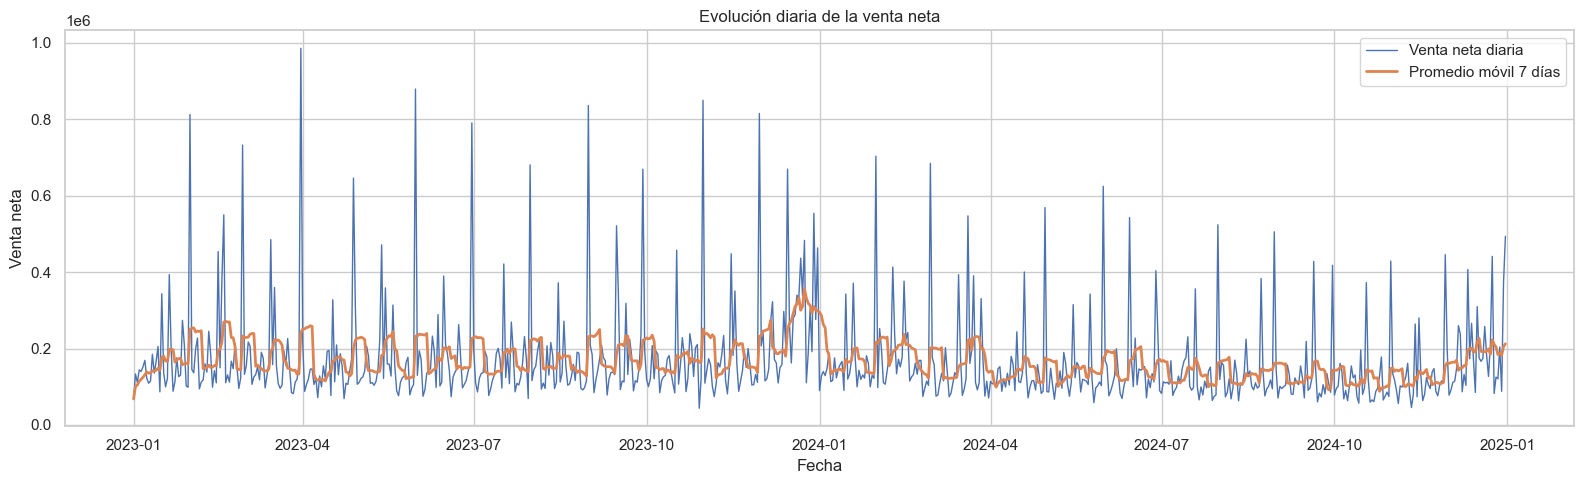

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\temporal\venta_neta_diaria_rolling_7d.png


In [7]:
# ===============================
# Serie diaria de venta neta
# ===============================

plt.figure(figsize=(16, 5))

sns.lineplot(
    data=ventas_diarias,
    x="FECHA",
    y="venta_neta",
    linewidth=1,
    label="Venta neta diaria"
)

sns.lineplot(
    data=ventas_diarias,
    x="FECHA",
    y="venta_neta_rolling_7d",
    linewidth=2,
    label="Promedio móvil 7 días"
)

plt.title("Evolución diaria de la venta neta")
plt.xlabel("Fecha")
plt.ylabel("Venta neta")
plt.legend()
plt.tight_layout()

output_fig = TEMPORAL_FIGURES_DIR / "venta_neta_diaria_rolling_7d.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

## Evolución diaria de la venta neta

La gráfica muestra la evolución diaria de la `VENTA_NETA` durante todo el periodo analizado, junto con un promedio móvil de 7 días que permite suavizar la variabilidad diaria.

La serie diaria presenta una alta variabilidad, con varios picos pronunciados de venta neta. Estos picos pueden estar relacionados con días comerciales especiales, promociones, cierres de mes, compras atípicas o registros de alto valor. Por esta razón, es importante no analizar únicamente los valores diarios aislados, sino también observar la tendencia suavizada.

El promedio móvil de 7 días permite identificar mejor el comportamiento general de la venta. Se observa que durante 2023 la venta mantiene varios periodos de mayor actividad y picos frecuentes. Hacia finales de 2023 e inicios de 2024 se presenta un aumento importante en la tendencia, lo que podría estar asociado a estacionalidad de fin de año o campañas comerciales.

Durante buena parte de 2024, la serie parece tener una tendencia más moderada en comparación con algunos periodos de 2023. Sin embargo, hacia el cierre de 2024 vuelve a observarse un incremento en la venta neta diaria, lo que puede indicar nuevamente un efecto estacional de final de año.

En conclusión, la venta neta diaria no es constante y presenta patrones temporales relevantes. Para entender mejor estas variaciones, es necesario complementar esta gráfica con análisis mensual, por día de la semana, por PDV, por categoría y con variables promocionales.

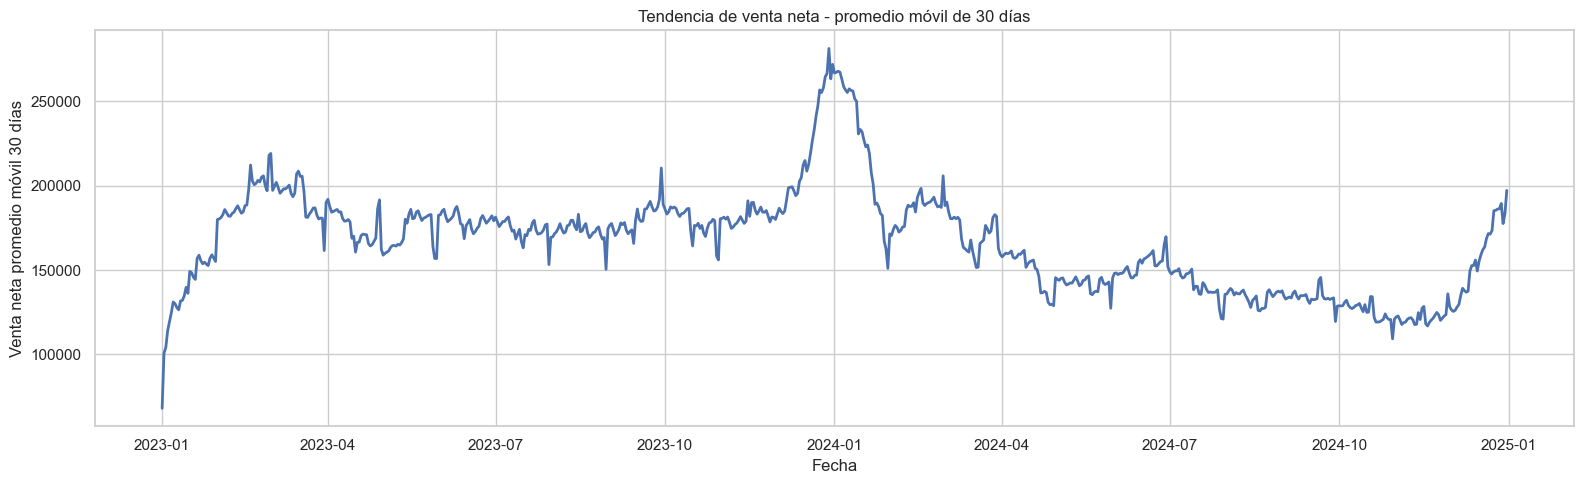

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\temporal\venta_neta_rolling_30d.png


In [8]:
# ===============================
# Tendencia suavizada de 30 días
# ===============================

plt.figure(figsize=(16, 5))

sns.lineplot(
    data=ventas_diarias,
    x="FECHA",
    y="venta_neta_rolling_30d",
    linewidth=2
)

plt.title("Tendencia de venta neta - promedio móvil de 30 días")
plt.xlabel("Fecha")
plt.ylabel("Venta neta promedio móvil 30 días")
plt.tight_layout()

output_fig = TEMPORAL_FIGURES_DIR / "venta_neta_rolling_30d.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

## Tendencia de venta neta con promedio móvil de 30 días

La gráfica muestra la tendencia de la `VENTA_NETA` utilizando un promedio móvil de 30 días. Esta visualización permite suavizar las variaciones diarias y observar con mayor claridad el comportamiento general de las ventas en el tiempo.

Al inicio de 2023 se observa un crecimiento progresivo de la venta neta promedio, pasando de niveles bajos en enero a valores cercanos o superiores a los **200.000** hacia el primer trimestre. Posteriormente, durante buena parte de 2023, la tendencia se mantiene relativamente estable, con fluctuaciones moderadas alrededor de un rango medio.

El punto más alto de la serie se presenta hacia finales de 2023 e inicios de 2024, donde la venta neta promedio móvil supera aproximadamente los **250.000**. Este comportamiento puede estar asociado a estacionalidad de fin de año, campañas comerciales, mayor actividad promocional o concentración de ventas en fechas especiales.

Después de ese pico, durante 2024 se observa una caída progresiva en la tendencia. La venta neta promedio disminuye especialmente entre el primer y segundo trimestre de 2024, y luego se mantiene en niveles más moderados durante varios meses.

Hacia finales de 2024 se evidencia nuevamente una recuperación marcada, lo cual puede indicar un efecto estacional similar al cierre del año anterior.

En conclusión, la venta neta presenta una tendencia con fuerte componente temporal: crecimiento inicial, pico importante al cierre de 2023, desaceleración durante 2024 y recuperación al final del periodo. Esto confirma la importancia de incluir variables temporales y medias móviles en una futura etapa de modelado predictivo.

In [9]:
# ===============================
# Agregación mensual
# ===============================

ventas_mensuales = (
    df.groupby(["ANIO", "MES", "MES_NOMBRE"])
    .agg(
        filas=("NroReg", "count"),
        dias=("FECHA", "nunique"),
        venta_bruta=("VENTA", "sum"),
        descuento=("DESCUENTO", "sum"),
        venta_neta=("VENTA_NETA", "sum"),
        unidades=("CANT", "sum"),
        tickets=("TICKET_ID", "nunique"),
        productos=("PLU_SAP", "nunique"),
        lineas_promo=("PROMO_FLAG", "sum")
    )
    .reset_index()
)

ventas_mensuales["FECHA_MES"] = pd.to_datetime(
    ventas_mensuales["ANIO"].astype(str) + "-" + ventas_mensuales["MES"].astype(str) + "-01"
)

ventas_mensuales["descuento_pct"] = np.where(
    ventas_mensuales["venta_bruta"] > 0,
    ventas_mensuales["descuento"] / ventas_mensuales["venta_bruta"] * 100,
    np.nan
)

ventas_mensuales["ticket_promedio_neto"] = np.where(
    ventas_mensuales["tickets"] > 0,
    ventas_mensuales["venta_neta"] / ventas_mensuales["tickets"],
    np.nan
)

ventas_mensuales["promo_pct_lineas"] = np.where(
    ventas_mensuales["filas"] > 0,
    ventas_mensuales["lineas_promo"] / ventas_mensuales["filas"] * 100,
    np.nan
)

ventas_mensuales = ventas_mensuales.sort_values("FECHA_MES")

ventas_mensuales

,ANIO,MES,MES_NOMBRE,filas,dias,venta_bruta,descuento,venta_neta,unidades,tickets,productos,lineas_promo,FECHA_MES,descuento_pct,ticket_promedio_neto,promo_pct_lineas
0,2023,1,Enero,19219,31,"6,211,723.00","745,966.00","5,465,757.00","22,597.54",12669,3026,5776,2023-01-01,12.01,431.43,30.05
1,2023,2,Febrero,18338,28,"6,300,692.00","672,380.00","5,628,312.00","22,347.45",12400,2947,5604,2023-02-01,10.67,453.90,30.56
2,2023,3,Marzo,19554,31,"6,691,739.00","859,475.00","5,832,264.00","22,791.83",12841,3030,6132,2023-03-01,12.84,454.19,31.36
3,2023,4,Abril,17026,30,"5,478,481.00","609,793.00","4,868,688.00","19,256.93",11494,2648,4974,2023-04-01,11.13,423.59,29.21
4,2023,5,Mayo,18277,31,"6,399,346.00","814,573.00","5,584,773.00","22,820.27",12397,2916,5196,2023-05-01,12.73,450.49,28.43
5,2023,6,Junio,18385,30,"6,172,996.00","796,728.00","5,376,268.00","22,858.76",12374,2899,5127,2023-06-01,12.91,434.48,27.89
6,2023,7,Julio,18324,31,"5,966,422.00","688,574.00","5,277,848.00","22,227.83",12391,2859,4968,2023-07-01,11.54,425.94,27.11
7,2023,8,Agosto,19176,31,"6,205,561.00","855,600.00","5,349,961.00","22,108.96",12850,2890,5549,2023-08-01,13.79,416.34,28.94
8,2023,9,Septiembre,18544,30,"6,306,122.00","635,949.00","5,670,173.00","22,987.99",13018,2749,4220,2023-09-01,10.08,435.56,22.76
9,2023,10,Octubre,17587,31,"6,407,604.00","877,939.00","5,529,665.00","21,856.50",11815,2808,5044,2023-10-01,13.70,468.02,28.68


## Resumen mensual de ventas

La tabla mensual permite observar el comportamiento de la venta neta, descuentos, unidades, tickets, productos y promociones a lo largo de los 24 meses disponibles.

Durante 2023, las ventas mensuales se mantienen relativamente estables en la mayoría de los meses, con valores de venta neta cercanos a los **5,2 y 5,8 millones**. Sin embargo, **diciembre de 2023** destaca claramente como el mes de mayor venta neta, con **8.362.453**, además de registrar el mayor número de filas, tickets y unidades de ese año. Esto sugiere un fuerte efecto estacional de fin de año.

En 2024 se observa un nivel de venta mensual más bajo en comparación con 2023. Los meses entre abril y noviembre de 2024 presentan ventas netas más moderadas, especialmente **septiembre**, **octubre** y **noviembre**, que se ubican por debajo de los 4 millones o cerca de ese rango. Esto coincide con la tendencia observada en las gráficas de promedio móvil, donde 2024 muestra una desaceleración durante buena parte del año.

A pesar de esa reducción, **diciembre de 2024** vuelve a mostrar una recuperación importante, con una venta neta de **5.993.121** y el ticket promedio neto más alto de la tabla, cercano a **500,68**. Esto refuerza la idea de que diciembre tiene un comportamiento comercial especial.

En cuanto a promociones, el porcentaje de líneas promocionales fue alto durante varios meses de 2023, superando el **30%** en enero, febrero, marzo y noviembre. En 2024, la intensidad promocional parece menor en algunos meses, aunque vuelve a aumentar en diciembre con **26,65%**.

También se observa que el descuento sobre venta bruta varía mensualmente. Diciembre de 2024 presenta un descuento relativo de **14,34%**, uno de los valores más altos, lo que puede estar relacionado con campañas comerciales o promociones de cierre de año.

En conclusión, el análisis mensual muestra una clara diferencia entre 2023 y 2024, así como un comportamiento estacional fuerte en diciembre. Para futuros modelos predictivos será importante incluir variables como mes, año, promociones, descuentos y efectos de fin de año.

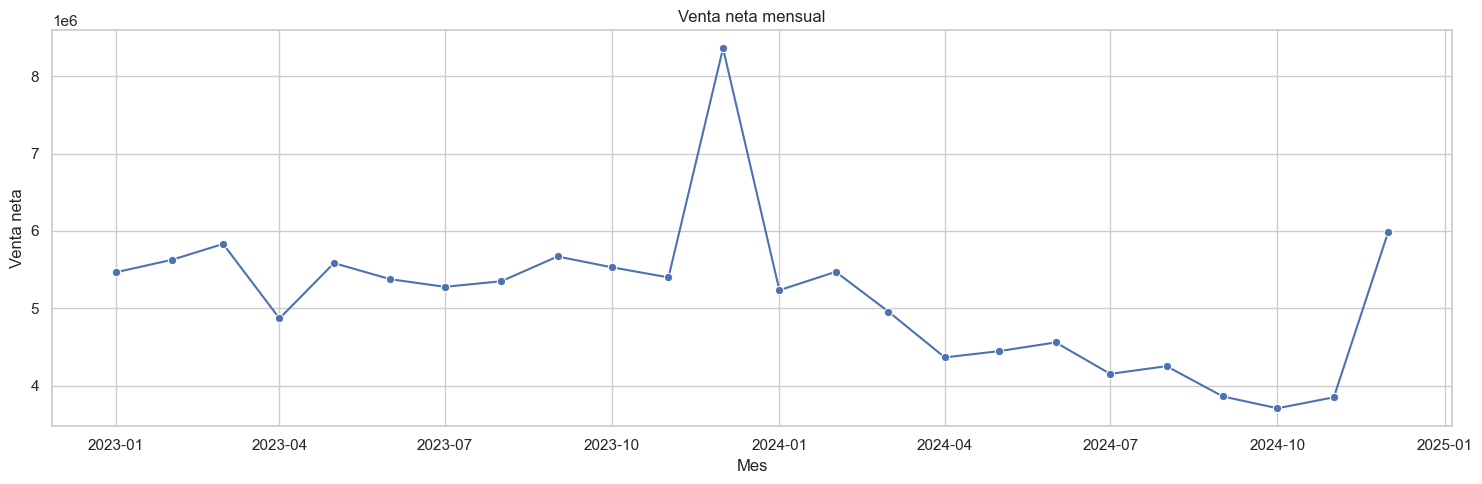

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\temporal\venta_neta_mensual.png


In [10]:
# ===============================
# Venta neta mensual
# ===============================

plt.figure(figsize=(15, 5))

sns.lineplot(
    data=ventas_mensuales,
    x="FECHA_MES",
    y="venta_neta",
    marker="o"
)

plt.title("Venta neta mensual")
plt.xlabel("Mes")
plt.ylabel("Venta neta")
plt.tight_layout()

output_fig = TEMPORAL_FIGURES_DIR / "venta_neta_mensual.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

## Evolución mensual de la venta neta

La gráfica muestra la evolución de la `VENTA_NETA` agregada por mes entre enero de 2023 y diciembre de 2024.

Durante la mayor parte de 2023, la venta mensual se mantiene relativamente estable, con valores cercanos a los **5 y 6 millones**. Sin embargo, en **diciembre de 2023** se observa un pico muy marcado, superando los **8 millones** de venta neta. Este comportamiento sugiere un fuerte efecto estacional asociado al cierre de año, posiblemente relacionado con mayor consumo, campañas comerciales o promociones de temporada.

En 2024 se evidencia una disminución frente a los niveles observados en 2023. Desde marzo hasta noviembre de 2024 la venta neta mensual se mantiene en niveles más bajos, con una caída progresiva que alcanza sus valores más bajos alrededor de septiembre, octubre y noviembre.

A pesar de esta desaceleración, en **diciembre de 2024** se observa una recuperación importante, alcanzando cerca de **6 millones** de venta neta. Esto refuerza la hipótesis de que diciembre tiene un comportamiento comercial especial dentro de la base.

En conclusión, la serie mensual evidencia diferencias claras entre años y una estacionalidad marcada en diciembre. Para futuros análisis y modelos predictivos, será importante incluir variables como mes, año, fin de año, promociones y descuentos.

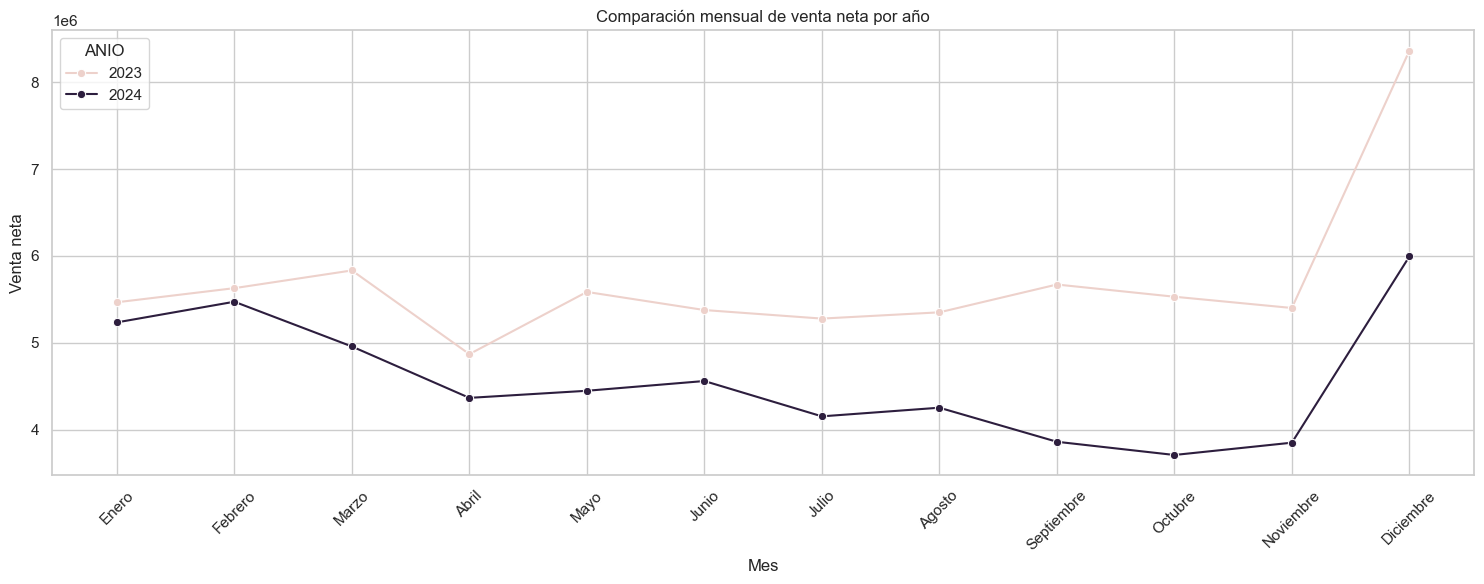

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\temporal\comparacion_mensual_2023_2024.png


In [11]:
# ===============================
# Comparación mensual por año
# ===============================

orden_meses = [
    "Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio",
    "Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre"
]

ventas_mensuales["MES_NOMBRE"] = pd.Categorical(
    ventas_mensuales["MES_NOMBRE"],
    categories=orden_meses,
    ordered=True
)

plt.figure(figsize=(15, 6))

sns.lineplot(
    data=ventas_mensuales,
    x="MES_NOMBRE",
    y="venta_neta",
    hue="ANIO",
    marker="o"
)

plt.title("Comparación mensual de venta neta por año")
plt.xlabel("Mes")
plt.ylabel("Venta neta")
plt.xticks(rotation=45)
plt.tight_layout()

output_fig = TEMPORAL_FIGURES_DIR / "comparacion_mensual_2023_2024.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

## Comparación mensual de venta neta por año

La gráfica compara la `VENTA_NETA` mensual entre los años **2023** y **2024**. Esta visualización permite identificar diferencias claras en el comportamiento comercial entre ambos periodos.

En términos generales, **2023 presenta niveles de venta neta superiores a 2024 en casi todos los meses**. Durante 2023, la venta mensual se mantiene relativamente estable entre enero y noviembre, con valores cercanos a los 5 y 6 millones. El mayor incremento se observa en diciembre, donde la venta neta alcanza su punto más alto del periodo.

En 2024, la venta neta inicia en niveles cercanos a 2023 durante enero y febrero, pero a partir de marzo se evidencia una caída frente al año anterior. Esta diferencia se mantiene durante gran parte del año, especialmente entre abril y noviembre, donde 2024 muestra ventas mensuales considerablemente menores.

El mes de diciembre presenta un comportamiento especial en ambos años. Tanto en 2023 como en 2024 se observa un aumento fuerte de la venta neta, lo que sugiere un efecto estacional asociado al cierre de año, posiblemente explicado por mayor consumo, promociones, campañas comerciales o cambios en la demanda.

En conclusión, la comparación anual muestra que 2024 tuvo un desempeño mensual inferior al de 2023 en la mayor parte del año, aunque ambos años comparten un patrón de crecimiento importante en diciembre. Esto confirma la importancia de incluir variables de año, mes y estacionalidad en futuros análisis y modelos predictivos.

In [12]:
# ===============================
# Variación mensual 2024 vs 2023
# ===============================

comparacion_mensual = ventas_mensuales.pivot_table(
    index=["MES", "MES_NOMBRE"],
    columns="ANIO",
    values="venta_neta",
    aggfunc="sum"
).reset_index()

comparacion_mensual.columns.name = None

if 2023 in comparacion_mensual.columns and 2024 in comparacion_mensual.columns:
    comparacion_mensual["variacion_abs_2024_vs_2023"] = comparacion_mensual[2024] - comparacion_mensual[2023]
    comparacion_mensual["variacion_pct_2024_vs_2023"] = np.where(
        comparacion_mensual[2023] != 0,
        comparacion_mensual["variacion_abs_2024_vs_2023"] / comparacion_mensual[2023] * 100,
        np.nan
    )

comparacion_mensual

,MES,MES_NOMBRE,2023,2024,variacion_abs_2024_vs_2023,variacion_pct_2024_vs_2023
0,1,Enero,"5,465,757.00","5,234,111.00","-231,646.00",-4.24
1,2,Febrero,"5,628,312.00","5,471,933.00","-156,379.00",-2.78
2,3,Marzo,"5,832,264.00","4,956,845.00","-875,419.00",-15.01
3,4,Abril,"4,868,688.00","4,364,964.00","-503,724.00",-10.35
4,5,Mayo,"5,584,773.00","4,446,615.00","-1,138,158.00",-20.38
5,6,Junio,"5,376,268.00","4,558,957.00","-817,311.00",-15.20
6,7,Julio,"5,277,848.00","4,152,159.00","-1,125,689.00",-21.33
7,8,Agosto,"5,349,961.00","4,251,683.00","-1,098,278.00",-20.53
8,9,Septiembre,"5,670,173.00","3,859,517.00","-1,810,656.00",-31.93
9,10,Octubre,"5,529,665.00","3,707,340.00","-1,822,325.00",-32.96


## Variación mensual de venta neta entre 2023 y 2024

La tabla compara la `VENTA_NETA` mensual de **2023** frente a **2024** y calcula tanto la variación absoluta como la variación porcentual entre ambos años.

Se observa que **todos los meses de 2024 presentan una venta neta menor que el mismo mes de 2023**. Las caídas más suaves se presentan en enero y febrero, con reducciones de **-4,24%** y **-2,78%**, respectivamente. Esto indica que al inicio de 2024 el comportamiento aún era relativamente cercano al del año anterior.

A partir de marzo, la diferencia se vuelve más marcada. Mayo, julio, agosto, septiembre, octubre, noviembre y diciembre presentan caídas superiores al **20%** frente a 2023. Los meses con mayor disminución porcentual son **octubre (-32,96%)**, **septiembre (-31,93%)**, **noviembre (-28,72%)** y **diciembre (-28,33%)**.

En términos absolutos, la mayor reducción ocurre en **diciembre**, con una diferencia de **-2.369.332** frente a diciembre de 2023. Aunque diciembre de 2024 sigue mostrando una recuperación frente a otros meses de 2024, no alcanza el nivel excepcional observado en diciembre de 2023.

Este resultado confirma una caída generalizada de la venta neta en 2024 respecto a 2023. Para interpretar correctamente esta diferencia, sería necesario revisar si hubo cambios en surtido, puntos de venta, promociones, comportamiento de clientes, condiciones del mercado, disponibilidad de productos o criterios de extracción de datos.

En conclusión, 2024 presenta un desempeño inferior a 2023 en todos los meses analizados. Esta diferencia debe considerarse en cualquier análisis temporal y en futuros modelos predictivos, ya que el año tiene un efecto claro sobre el nivel de ventas.

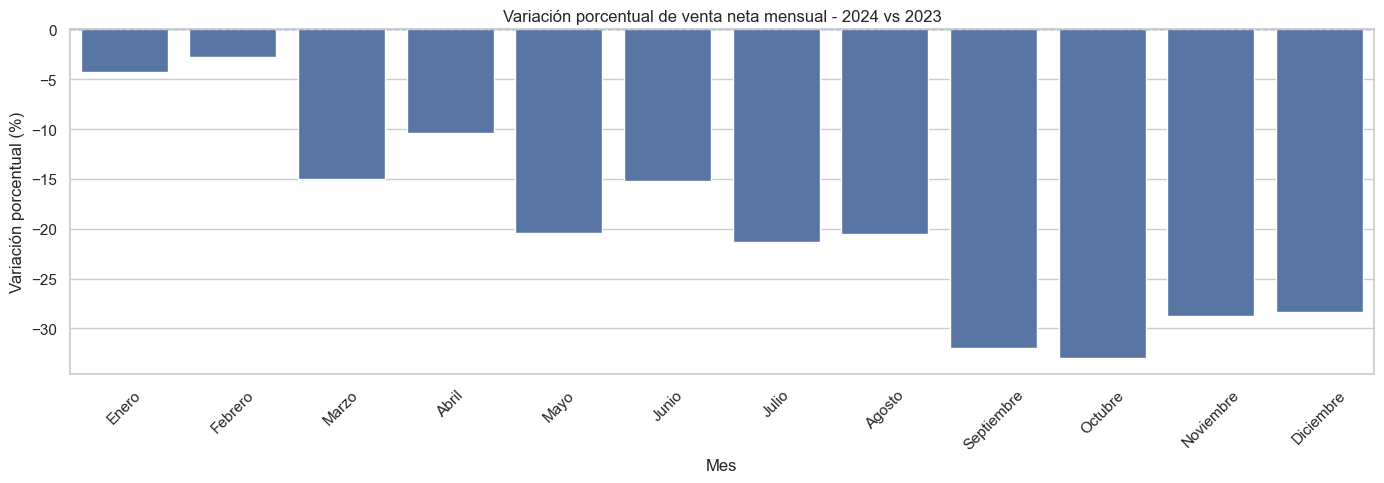

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\temporal\variacion_pct_mensual_2024_vs_2023.png


In [13]:
# ===============================
# Gráfico variación porcentual 2024 vs 2023
# ===============================

if "variacion_pct_2024_vs_2023" in comparacion_mensual.columns:
    plt.figure(figsize=(14, 5))

    sns.barplot(
        data=comparacion_mensual,
        x="MES_NOMBRE",
        y="variacion_pct_2024_vs_2023"
    )

    plt.axhline(0, linestyle="--", linewidth=1)
    plt.title("Variación porcentual de venta neta mensual - 2024 vs 2023")
    plt.xlabel("Mes")
    plt.ylabel("Variación porcentual (%)")
    plt.xticks(rotation=45)
    plt.tight_layout()

    output_fig = TEMPORAL_FIGURES_DIR / "variacion_pct_mensual_2024_vs_2023.png"
    plt.savefig(output_fig, dpi=300, bbox_inches="tight")

    plt.show()

    print(f"Figura guardada en: {output_fig}")

## Variación porcentual mensual de venta neta: 2024 vs 2023

La gráfica muestra la variación porcentual de la `VENTA_NETA` mensual de **2024** frente al mismo mes de **2023**.

Se observa que todos los meses presentan variaciones negativas, lo que confirma que en **2024 la venta neta fue menor que en 2023 durante todo el año**. Las menores caídas se presentan en **enero** y **febrero**, con reducciones moderadas cercanas al 4% y 3%, respectivamente.

A partir de marzo, la disminución se vuelve más fuerte. Meses como **mayo**, **julio**, **agosto**, **septiembre**, **octubre**, **noviembre** y **diciembre** presentan caídas superiores al 20%, lo cual evidencia una diferencia comercial importante entre ambos años.

Los meses más críticos son **septiembre** y **octubre**, con reducciones cercanas o superiores al 30%. Esto indica que durante el segundo semestre de 2024 se presentó una desaceleración marcada frente al comportamiento observado en 2023.

Aunque diciembre de 2024 muestra una recuperación en términos absolutos frente a meses anteriores del mismo año, la gráfica evidencia que sigue estando por debajo de diciembre de 2023. Esto confirma que el pico de diciembre de 2023 fue considerablemente más alto.

En conclusión, la gráfica refuerza que el año 2024 tuvo un desempeño inferior al de 2023 en todos los meses. Esta diferencia debe analizarse con mayor profundidad revisando factores como promociones, descuentos, surtido de productos, cantidad de tickets, comportamiento por PDV y posibles cambios en la operación o extracción de datos.

In [14]:
# ===============================
# Agregación semanal
# ===============================

ventas_semanales = (
    df.set_index("FECHA")
    .resample("W-MON")
    .agg(
        filas=("NroReg", "count"),
        venta_bruta=("VENTA", "sum"),
        descuento=("DESCUENTO", "sum"),
        venta_neta=("VENTA_NETA", "sum"),
        unidades=("CANT", "sum"),
        tickets=("TICKET_ID", "nunique"),
        productos=("PLU_SAP", "nunique"),
        lineas_promo=("PROMO_FLAG", "sum")
    )
    .reset_index()
)

ventas_semanales["descuento_pct"] = np.where(
    ventas_semanales["venta_bruta"] > 0,
    ventas_semanales["descuento"] / ventas_semanales["venta_bruta"] * 100,
    np.nan
)

ventas_semanales["promo_pct_lineas"] = np.where(
    ventas_semanales["filas"] > 0,
    ventas_semanales["lineas_promo"] / ventas_semanales["filas"] * 100,
    np.nan
)

ventas_semanales.head()

,FECHA,filas,venta_bruta,descuento,venta_neta,unidades,tickets,productos,lineas_promo,descuento_pct,promo_pct_lineas
0,2023-01-02,719,"204,435.00","2,906.00","201,529.00",960.98,512,410,46,1.42,6.40
1,2023-01-09,3570,"984,448.00","36,222.00","948,226.00","4,758.93",2591,1165,378,3.68,10.59
2,2023-01-16,4592,"1,380,024.00","142,986.00","1,237,038.00","4,919.24",3010,1584,1647,10.36,35.87
3,2023-01-23,3692,"1,266,050.00","116,039.00","1,150,011.00","4,448.37",2540,1343,881,9.17,23.86
4,2023-01-30,4070,"1,196,164.00","79,480.00","1,116,684.00","4,618.78",2985,1344,786,6.64,19.31


## Construcción de la base semanal de ventas

La tabla muestra una agregación de la información a nivel semanal, donde cada fila resume el comportamiento de ventas para una semana específica.

En esta vista se consolidan métricas como número de registros, venta bruta, descuento, venta neta, unidades vendidas, tickets únicos, productos vendidos y líneas promocionales. Esto permite analizar la evolución de las ventas con menor ruido que en la serie diaria.

Durante las primeras semanas de enero de 2023 se observa un aumento importante en el volumen de actividad. Por ejemplo, la semana asociada al **2023-01-02** registra una venta neta de **201.529**, mientras que la semana del **2023-01-16** alcanza **1.237.038**. Esto muestra que la primera semana puede estar incompleta o tener menor actividad, mientras que las semanas siguientes ya reflejan una operación más estable.

También se observa que el número de tickets, productos y unidades aumenta considerablemente a partir de la segunda semana. Esto confirma que el análisis semanal ayuda a identificar patrones más claros de comportamiento comercial.

El porcentaje de descuento y el porcentaje de líneas promocionales también varían entre semanas. Por ejemplo, la semana del **2023-01-16** presenta un porcentaje de líneas promocionales de **35,87%**, mucho mayor que las semanas anteriores. Esto puede estar relacionado con campañas promocionales o eventos comerciales específicos.

En conclusión, la agregación semanal permite analizar la tendencia de ventas de forma más estable que la vista diaria. Esta tabla será útil para identificar semanas de alta actividad, semanas promocionales y posibles patrones estacionales.

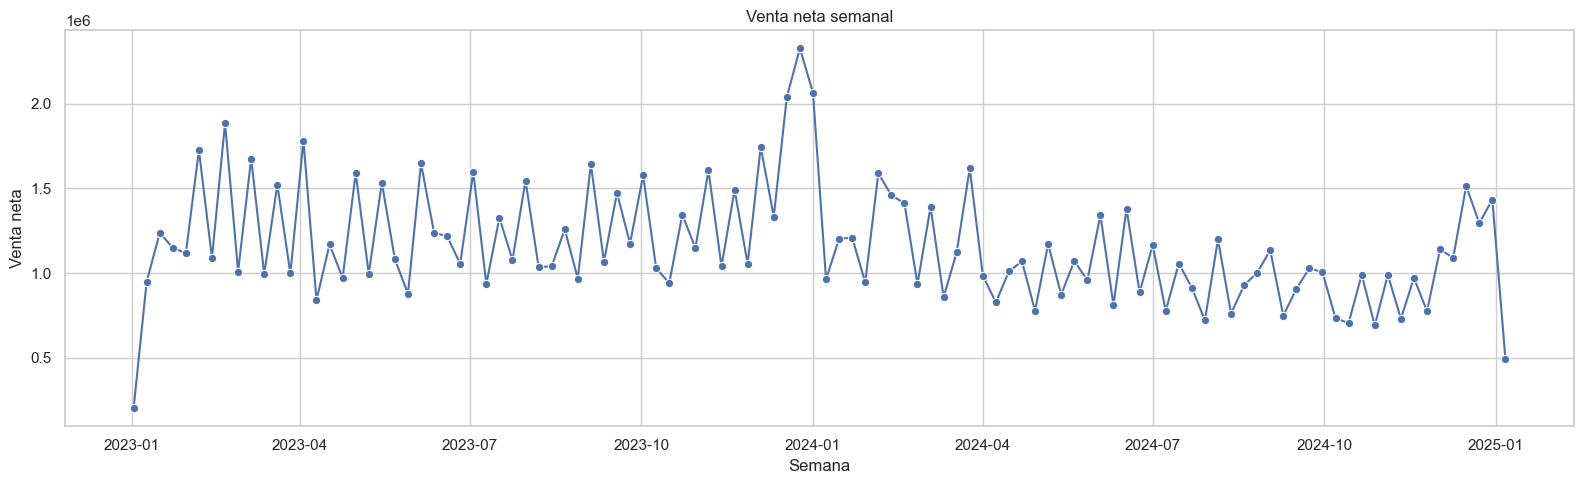

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\temporal\venta_neta_semanal.png


In [15]:
# ===============================
# Serie semanal de venta neta
# ===============================

plt.figure(figsize=(16, 5))

sns.lineplot(
    data=ventas_semanales,
    x="FECHA",
    y="venta_neta",
    marker="o"
)

plt.title("Venta neta semanal")
plt.xlabel("Semana")
plt.ylabel("Venta neta")
plt.tight_layout()

output_fig = TEMPORAL_FIGURES_DIR / "venta_neta_semanal.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

## Evolución semanal de la venta neta

La gráfica muestra la evolución de la `VENTA_NETA` agregada por semana. Este nivel de análisis permite reducir el ruido diario y observar con mayor claridad los cambios generales en el comportamiento de ventas.

Al inicio de enero de 2023 se observa una venta semanal baja, lo cual puede deberse a que la primera semana del periodo está incompleta o tiene menor actividad comercial. A partir de las semanas siguientes, la venta semanal aumenta y se mantiene con fluctuaciones importantes durante 2023.

Durante 2023 se presentan varios picos semanales, con valores superiores a un millón de venta neta. El mayor pico se observa hacia finales de 2023 e inicios de 2024, superando los dos millones, lo que coincide con el comportamiento estacional identificado en diciembre.

En 2024 se aprecia una reducción general en la venta semanal frente a los niveles de 2023. Durante buena parte del año, la serie se mantiene en rangos más bajos, aunque conserva cierta variabilidad entre semanas.

Hacia finales de 2024 se observa una recuperación importante, nuevamente asociada al cierre de año. Sin embargo, el último punto de la serie cae de forma marcada, probablemente porque corresponde a una semana incompleta al final del periodo.

En conclusión, la serie semanal confirma una estacionalidad fuerte al cierre de año y una disminución general del nivel de ventas durante 2024. Para futuros modelos, esta vista semanal puede servir para validar tendencias y comparar el comportamiento frente a la serie diaria.

In [16]:
# ===============================
# Resumen anual
# ===============================

resumen_anual = (
    df.groupby("ANIO")
    .agg(
        filas=("NroReg", "count"),
        dias=("FECHA", "nunique"),
        venta_bruta=("VENTA", "sum"),
        descuento=("DESCUENTO", "sum"),
        venta_neta=("VENTA_NETA", "sum"),
        unidades=("CANT", "sum"),
        tickets=("TICKET_ID", "nunique"),
        productos=("PLU_SAP", "nunique"),
        lineas_promo=("PROMO_FLAG", "sum")
    )
    .reset_index()
)

resumen_anual["descuento_pct"] = np.where(
    resumen_anual["venta_bruta"] > 0,
    resumen_anual["descuento"] / resumen_anual["venta_bruta"] * 100,
    np.nan
)

resumen_anual["ticket_promedio_neto"] = np.where(
    resumen_anual["tickets"] > 0,
    resumen_anual["venta_neta"] / resumen_anual["tickets"],
    np.nan
)

resumen_anual["promo_pct_lineas"] = np.where(
    resumen_anual["filas"] > 0,
    resumen_anual["lineas_promo"] / resumen_anual["filas"] * 100,
    np.nan
)

resumen_anual

,ANIO,filas,dias,venta_bruta,descuento,venta_neta,unidades,tickets,productos,lineas_promo,descuento_pct,ticket_promedio_neto,promo_pct_lineas
0,2023,228150,365,"78,121,622.00","9,775,494.00","68,346,128.00","278,784.76",152896,5410,65612,12.51,447.01,28.76
1,2024,181610,366,"61,340,876.00","6,494,642.00","54,846,234.00","216,188.47",124093,4845,43627,10.59,441.98,24.02


## Resumen anual de ventas

La tabla compara el comportamiento general de las ventas entre **2023** y **2024**. Aunque ambos años tienen cobertura completa, con **365 días en 2023** y **366 días en 2024**, se observan diferencias importantes en volumen y desempeño comercial.

En **2023** se registraron **228.150 filas**, una venta bruta de **78.121.622**, descuentos por **9.775.494** y una venta neta total de **68.346.128**. También se registraron **278.784,76 unidades**, **152.896 tickets** y **5.410 productos únicos**.

En **2024**, el volumen fue menor: **181.610 filas**, venta bruta de **61.340.876**, descuentos por **6.494.642** y venta neta de **54.846.234**. También disminuyeron las unidades vendidas, los tickets y los productos únicos frente a 2023.

El porcentaje de descuento sobre la venta bruta fue mayor en 2023, con **12,51%**, frente a **10,59%** en 2024. Además, la proporción de líneas promocionales también fue más alta en 2023, con **28,76%**, mientras que en 2024 fue de **24,02%**.

El ticket promedio neto se mantiene relativamente similar entre ambos años: **447,01** en 2023 y **441,98** en 2024. Esto sugiere que la caída de 2024 no se debe principalmente a una reducción fuerte en el valor promedio por ticket, sino más bien a una disminución en la cantidad de tickets, filas, unidades y productos vendidos.

En conclusión, 2024 presenta menor actividad comercial que 2023 en casi todas las métricas principales. Para entender esta diferencia, será importante revisar el comportamiento por PDV, categoría, promociones, productos y tickets.

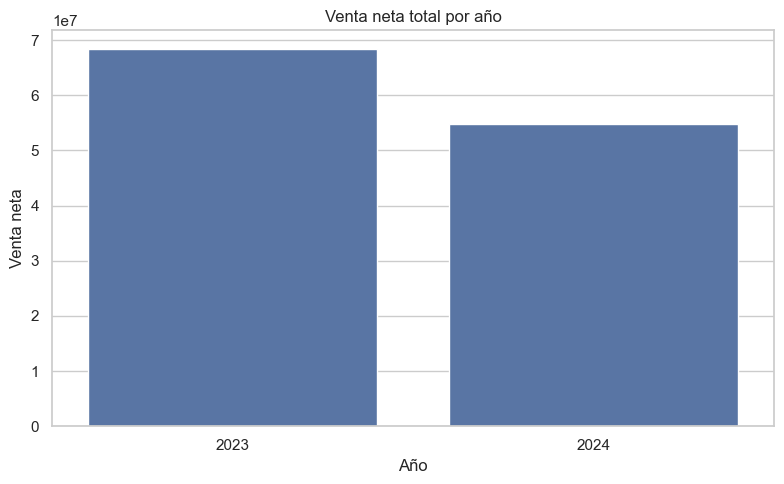

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\temporal\venta_neta_por_anio.png


In [17]:
# ===============================
# Venta neta por año
# ===============================

plt.figure(figsize=(8, 5))

sns.barplot(
    data=resumen_anual,
    x="ANIO",
    y="venta_neta"
)

plt.title("Venta neta total por año")
plt.xlabel("Año")
plt.ylabel("Venta neta")
plt.tight_layout()

output_fig = TEMPORAL_FIGURES_DIR / "venta_neta_por_anio.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

## Comparación de venta neta total por año

El gráfico compara la `VENTA_NETA` total entre **2023** y **2024**.

Se observa que **2023 presenta una venta neta total superior a 2024**. En 2023 la venta neta alcanza aproximadamente **68,3 millones**, mientras que en 2024 se ubica alrededor de **54,8 millones**.

Esta diferencia confirma visualmente lo observado en la tabla anual: aunque ambos años tienen cobertura completa de días, el volumen de ventas fue considerablemente menor en 2024.

La caída no parece explicarse por falta de fechas, ya que 2024 incluso tiene un día adicional por ser año bisiesto. Por tanto, la disminución debe analizarse desde variables comerciales como cantidad de tickets, unidades vendidas, productos activos, promociones, descuentos, comportamiento por PDV y categorías.

En conclusión, el año 2024 muestra un desempeño inferior frente a 2023 en términos de venta neta total. Esta diferencia anual debe considerarse en el análisis temporal y en cualquier modelo predictivo, ya que el año puede estar capturando cambios importantes en la dinámica comercial.

In [18]:
# ===============================
# Resumen por día de la semana
# ===============================

orden_dias = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]

resumen_dia_semana = (
    df.groupby(["DIA_SEMANA_NUM", "DIA_SEMANA_NOMBRE"])
    .agg(
        filas=("NroReg", "count"),
        dias=("FECHA", "nunique"),
        venta_bruta=("VENTA", "sum"),
        descuento=("DESCUENTO", "sum"),
        venta_neta=("VENTA_NETA", "sum"),
        unidades=("CANT", "sum"),
        tickets=("TICKET_ID", "nunique"),
        lineas_promo=("PROMO_FLAG", "sum")
    )
    .reset_index()
    .sort_values("DIA_SEMANA_NUM")
)

resumen_dia_semana["venta_neta_promedio_dia"] = resumen_dia_semana["venta_neta"] / resumen_dia_semana["dias"]

resumen_dia_semana["ticket_promedio_neto"] = np.where(
    resumen_dia_semana["tickets"] > 0,
    resumen_dia_semana["venta_neta"] / resumen_dia_semana["tickets"],
    np.nan
)

resumen_dia_semana["promo_pct_lineas"] = np.where(
    resumen_dia_semana["filas"] > 0,
    resumen_dia_semana["lineas_promo"] / resumen_dia_semana["filas"] * 100,
    np.nan
)

resumen_dia_semana["DIA_SEMANA_NOMBRE"] = pd.Categorical(
    resumen_dia_semana["DIA_SEMANA_NOMBRE"],
    categories=orden_dias,
    ordered=True
)

resumen_dia_semana

,DIA_SEMANA_NUM,DIA_SEMANA_NOMBRE,filas,dias,venta_bruta,descuento,venta_neta,unidades,tickets,lineas_promo,venta_neta_promedio_dia,ticket_promedio_neto,promo_pct_lineas
0,0,Lunes,49925,105,"15,854,270.00","1,521,119.00","14,333,151.00","56,996.35",33825,13538,"136,506.20",423.74,27.12
1,1,Martes,54597,105,"18,436,595.00","2,103,512.00","16,333,083.00","63,219.81",37152,13268,"155,553.17",439.63,24.30
2,2,Miércoles,61230,104,"20,906,670.00","2,432,516.00","18,474,154.00","68,204.51",40346,20633,"177,636.10",457.89,33.70
3,3,Jueves,56815,104,"19,084,477.00","1,996,787.00","17,087,690.00","66,226.70",39150,13360,"164,304.71",436.47,23.51
4,4,Viernes,86999,104,"32,986,080.00","5,556,364.00","27,429,716.00","104,517.04",54430,31668,"263,747.27",503.94,36.40
5,5,Sábado,62417,104,"21,155,398.00","1,984,662.00","19,170,736.00","88,640.25",44608,11340,"184,334.00",429.76,18.17
6,6,Domingo,37777,105,"11,039,008.00","675,176.00","10,363,832.00","47,168.56",27478,5432,"98,703.16",377.17,14.38


## Resumen por día de la semana

La tabla muestra el comportamiento de las ventas agrupado por día de la semana. Este análisis permite identificar si existen patrones comerciales diferentes entre lunes, martes, miércoles, jueves, viernes, sábado y domingo.

El día con mayor venta neta total es **viernes**, con **27.429.716**, seguido por **sábado** con **19.170.736** y **miércoles** con **18.474.154**. Esto indica que el viernes es el día de mayor actividad comercial dentro de la base, tanto en venta neta como en número de filas, unidades, tickets y líneas promocionales.

El viernes también presenta el mayor `ticket_promedio_neto`, con **503,94**, y la mayor venta neta promedio por día, con **263.747,27**. Además, tiene el porcentaje más alto de líneas promocionales, con **36,40%**, lo que sugiere que la mayor actividad de ventas puede estar relacionada con una mayor intensidad promocional.

El miércoles también se destaca por tener un porcentaje alto de líneas promocionales, con **33,70%**, además de una venta promedio diaria importante. Esto puede indicar que existen dinámicas promocionales o comerciales específicas a mitad de semana.

Por otro lado, el **domingo** presenta los valores más bajos en venta neta, tickets, filas y ticket promedio neto. Su porcentaje de líneas promocionales también es el menor, con **14,38%**, lo que sugiere una menor actividad comercial en ese día.

En conclusión, las ventas no se distribuyen de manera uniforme durante la semana. El viernes concentra la mayor actividad comercial, mientras que el domingo presenta el menor desempeño. Por esta razón, el día de la semana debe incluirse como una variable importante en el análisis temporal y en futuros modelos predictivos.

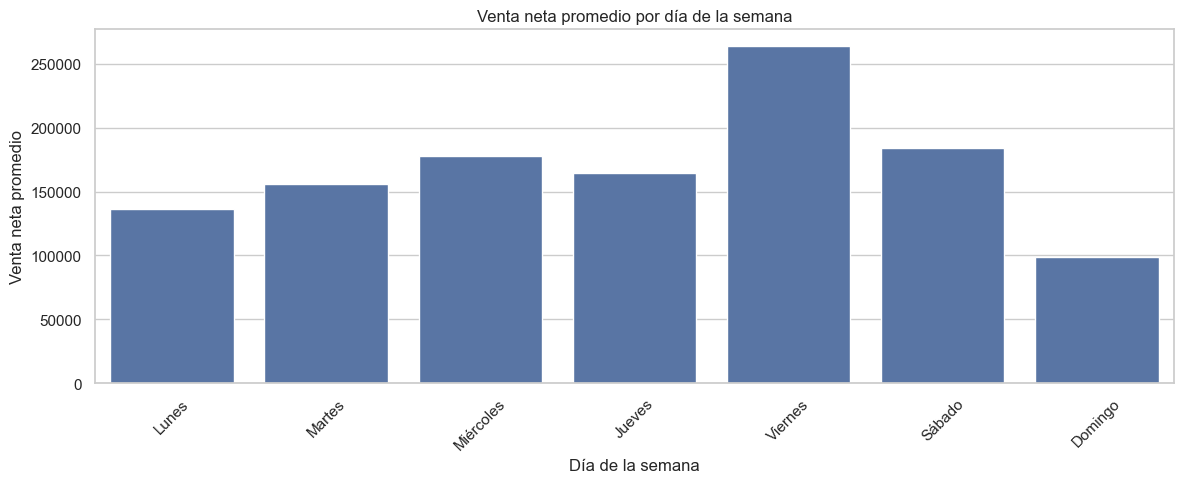

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\temporal\venta_promedio_dia_semana.png


In [19]:
# ===============================
# Venta neta promedio por día de semana
# ===============================

plt.figure(figsize=(12, 5))

sns.barplot(
    data=resumen_dia_semana,
    x="DIA_SEMANA_NOMBRE",
    y="venta_neta_promedio_dia"
)

plt.title("Venta neta promedio por día de la semana")
plt.xlabel("Día de la semana")
plt.ylabel("Venta neta promedio")
plt.xticks(rotation=45)
plt.tight_layout()

output_fig = TEMPORAL_FIGURES_DIR / "venta_promedio_dia_semana.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

## Venta neta promedio por día de la semana

La gráfica muestra la venta neta promedio según el día de la semana. Se observa que el **viernes** es el día con mayor venta neta promedio, con un valor claramente superior al resto de días.

Después del viernes, los días con mejor comportamiento son **sábado** y **miércoles**, lo cual indica que la actividad comercial no se distribuye de forma uniforme durante la semana.

Por el contrario, el **domingo** presenta la menor venta neta promedio. Esto puede estar relacionado con menor tráfico de clientes, horarios de operación, hábitos de compra o menor intensidad promocional durante ese día.

Este resultado confirma que el día de la semana influye en el comportamiento de las ventas. Por tanto, variables como `DIA_SEMANA_NOMBRE`, `FIN_SEMANA` y posiblemente una bandera específica para viernes pueden ser útiles en futuros análisis y modelos predictivos.

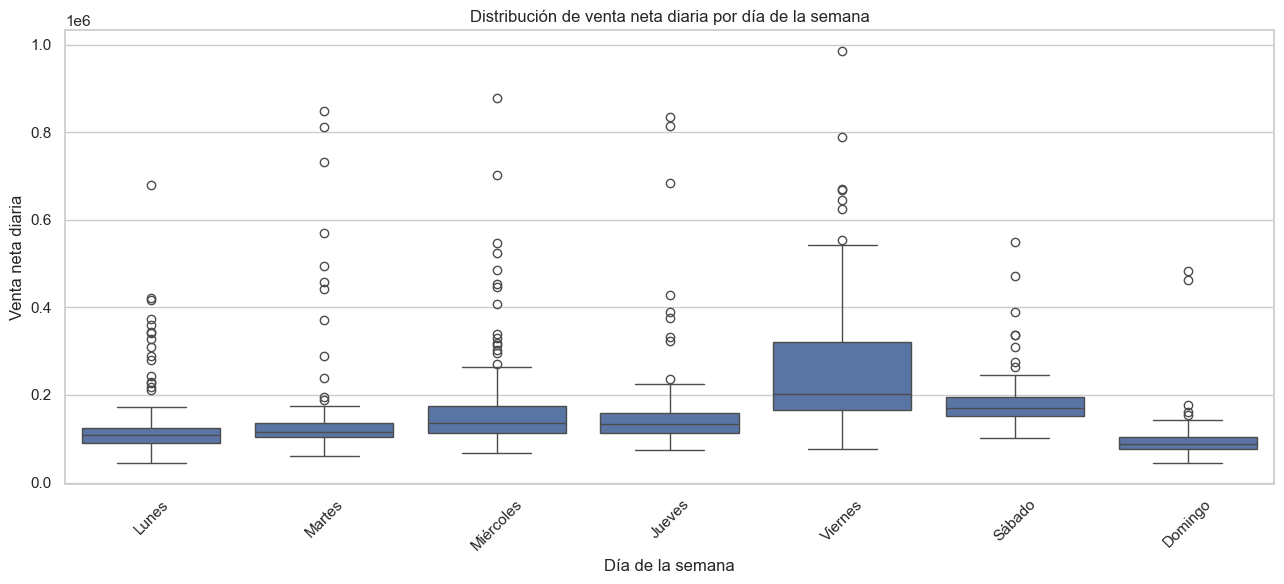

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\temporal\boxplot_venta_diaria_dia_semana.png


In [20]:
# ===============================
# Boxplot de venta diaria por día de semana
# ===============================

ventas_diarias_contexto = ventas_diarias.copy()
ventas_diarias_contexto["DIA_SEMANA_NUM"] = ventas_diarias_contexto["FECHA"].dt.dayofweek
ventas_diarias_contexto["DIA_SEMANA_NOMBRE"] = ventas_diarias_contexto["DIA_SEMANA_NUM"].map({
    0: "Lunes",
    1: "Martes",
    2: "Miércoles",
    3: "Jueves",
    4: "Viernes",
    5: "Sábado",
    6: "Domingo"
})

ventas_diarias_contexto["DIA_SEMANA_NOMBRE"] = pd.Categorical(
    ventas_diarias_contexto["DIA_SEMANA_NOMBRE"],
    categories=orden_dias,
    ordered=True
)

plt.figure(figsize=(13, 6))

sns.boxplot(
    data=ventas_diarias_contexto,
    x="DIA_SEMANA_NOMBRE",
    y="venta_neta"
)

plt.title("Distribución de venta neta diaria por día de la semana")
plt.xlabel("Día de la semana")
plt.ylabel("Venta neta diaria")
plt.xticks(rotation=45)
plt.tight_layout()

output_fig = TEMPORAL_FIGURES_DIR / "boxplot_venta_diaria_dia_semana.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

## Distribución de venta neta diaria por día de la semana

El boxplot muestra cómo se distribuye la `VENTA_NETA` diaria según el día de la semana. Esta visualización permite comparar no solo el promedio, sino también la variabilidad y la presencia de días atípicos.

Se observa que el **viernes** presenta la mayor dispersión y los valores diarios más altos de venta neta. Su mediana también es superior a la de la mayoría de los días, lo que confirma que es el día con mayor actividad comercial. Además, aparecen varios valores extremos, lo cual puede estar relacionado con promociones, cierres comerciales o eventos de alta venta.

El **sábado** también muestra un comportamiento fuerte, con una mediana relativamente alta y menor dispersión que el viernes. Esto sugiere que el sábado tiene ventas importantes, pero más estables.

Los días de lunes a jueves presentan niveles intermedios de venta neta, aunque también se observan valores atípicos altos, especialmente martes, miércoles y jueves. Estos picos pueden corresponder a fechas puntuales con promociones o ventas extraordinarias.

El **domingo** presenta la distribución más baja, con menor mediana y menor rango de ventas en comparación con los demás días. Aunque existen algunos valores atípicos, en general su comportamiento confirma una menor actividad comercial.

En conclusión, la venta neta diaria varía considerablemente según el día de la semana. El viernes destaca como el día más fuerte en ventas y el domingo como el más bajo. Esta diferencia confirma que el día de la semana debe considerarse una variable importante en el análisis temporal y en futuros modelos predictivos.

In [21]:
# ===============================
# Resumen por mes
# ===============================

resumen_mes = (
    df.groupby(["MES", "MES_NOMBRE"])
    .agg(
        filas=("NroReg", "count"),
        dias=("FECHA", "nunique"),
        venta_bruta=("VENTA", "sum"),
        descuento=("DESCUENTO", "sum"),
        venta_neta=("VENTA_NETA", "sum"),
        unidades=("CANT", "sum"),
        tickets=("TICKET_ID", "nunique"),
        lineas_promo=("PROMO_FLAG", "sum")
    )
    .reset_index()
    .sort_values("MES")
)

resumen_mes["venta_neta_promedio_dia"] = resumen_mes["venta_neta"] / resumen_mes["dias"]

resumen_mes["MES_NOMBRE"] = pd.Categorical(
    resumen_mes["MES_NOMBRE"],
    categories=orden_meses,
    ordered=True
)

resumen_mes

,MES,MES_NOMBRE,filas,dias,venta_bruta,descuento,venta_neta,unidades,tickets,lineas_promo,venta_neta_promedio_dia
0,1,Enero,36928,62,"12,132,778.00","1,432,910.00","10,699,868.00","44,716.38",24714,9642,"172,578.52"
1,2,Febrero,35959,57,"12,211,330.00","1,111,085.00","11,100,245.00","43,997.42",24290,9394,"194,741.14"
2,3,Marzo,35497,62,"12,140,750.00","1,351,641.00","10,789,109.00","43,482.22",23732,10412,"174,017.89"
3,4,Abril,31767,60,"10,284,621.00","1,050,969.00","9,233,652.00","35,630.20",21494,8443,"153,894.20"
4,5,Mayo,33565,62,"11,421,813.00","1,390,425.00","10,031,388.00","39,697.26",22899,8929,"161,796.58"
5,6,Junio,33385,60,"11,223,861.00","1,288,636.00","9,935,225.00","39,782.60",22610,8669,"165,587.08"
6,7,Julio,32506,62,"10,535,169.00","1,105,162.00","9,430,007.00","37,832.40",22066,8124,"152,096.89"
7,8,Agosto,33427,62,"11,010,954.00","1,409,310.00","9,601,644.00","38,138.95",22679,9055,"154,865.23"
8,9,Septiembre,31936,60,"10,600,125.00","1,070,435.00","9,529,690.00","37,726.80",22285,7583,"158,828.17"
9,10,Octubre,30224,62,"10,581,867.00","1,344,862.00","9,237,005.00","36,663.72",20608,8081,"148,983.95"


## Comportamiento acumulado por mes

La tabla resume el comportamiento de las ventas agrupando los meses de ambos años disponibles, es decir, consolida enero de 2023 y enero de 2024, febrero de 2023 y febrero de 2024, y así sucesivamente.

Se observa que **diciembre** es el mes con mayor actividad comercial. Registra **43.829 filas**, **28.842 tickets**, **59.252,04 unidades** y una venta neta total de **14.355.574**. Además, tiene la mayor venta neta promedio diaria, con **231.541,52**, lo que confirma un fuerte efecto estacional de fin de año.

Después de diciembre, los meses con mayor venta neta acumulada son **febrero**, **marzo** y **enero**, todos por encima de los 10 millones. Febrero destaca especialmente porque, aunque tiene menos días observados que enero y marzo, presenta una venta neta promedio diaria alta de **194.741,14**.

Los meses con menor venta neta acumulada son **abril**, **octubre** y **noviembre**, con valores cercanos a los 9,2 millones. Esto sugiere que, en promedio, estos meses presentan menor actividad comercial dentro del periodo analizado.

También se observa que diciembre concentra el mayor número de líneas promocionales, con **12.152**, seguido por marzo, enero y febrero. Esto puede indicar que la mayor venta de diciembre está acompañada por una mayor actividad promocional.

En conclusión, el análisis mensual acumulado muestra que las ventas tienen un componente estacional importante. Diciembre se comporta como el mes más fuerte del año, mientras que meses como abril, octubre y noviembre presentan menor desempeño relativo. Por esta razón, el mes debe considerarse una variable relevante en el análisis temporal y en futuros modelos predictivos.

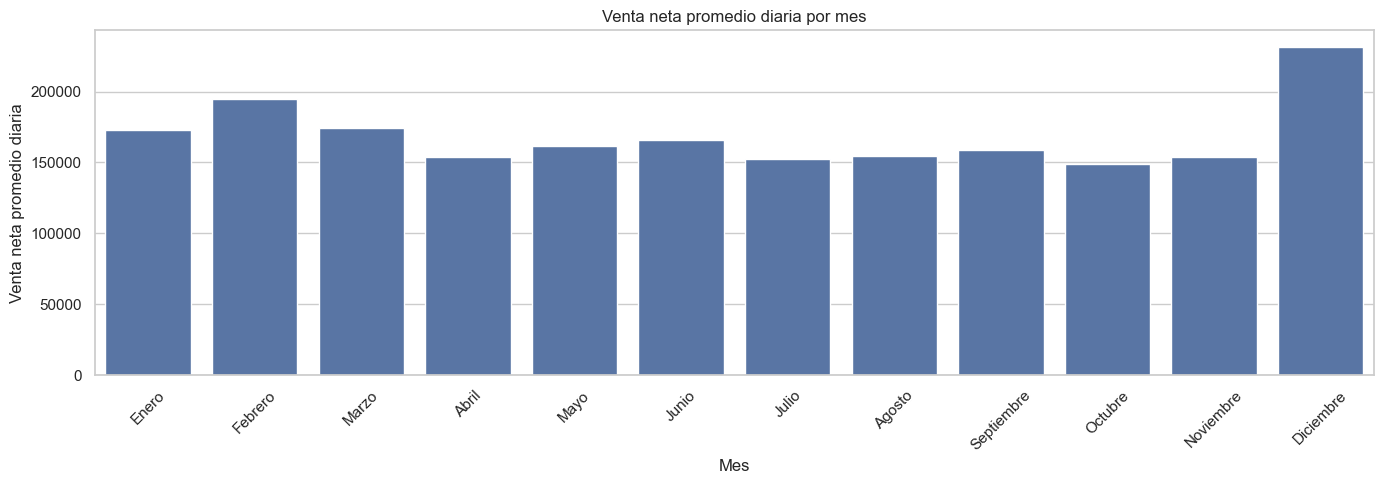

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\temporal\venta_promedio_diaria_por_mes.png


In [22]:
# ===============================
# Venta neta promedio por mes
# ===============================

plt.figure(figsize=(14, 5))

sns.barplot(
    data=resumen_mes,
    x="MES_NOMBRE",
    y="venta_neta_promedio_dia"
)

plt.title("Venta neta promedio diaria por mes")
plt.xlabel("Mes")
plt.ylabel("Venta neta promedio diaria")
plt.xticks(rotation=45)
plt.tight_layout()

output_fig = TEMPORAL_FIGURES_DIR / "venta_promedio_diaria_por_mes.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

## Venta neta promedio diaria por mes

La gráfica muestra la `VENTA_NETA` promedio diaria para cada mes, consolidando la información de los dos años disponibles.

Se observa que **diciembre** es el mes con mayor venta neta promedio diaria, superando claramente al resto de meses. Esto confirma nuevamente que el cierre de año tiene un comportamiento comercial especial, probablemente asociado a mayor consumo, promociones, temporada navideña o campañas comerciales.

Después de diciembre, **febrero** también presenta un promedio diario alto, seguido por meses como enero y marzo. Esto indica que no solo el volumen mensual total es importante, sino también cuánta venta se genera en promedio por día dentro de cada mes.

Los meses con menor venta neta promedio diaria son **octubre**, **julio**, **abril** y **noviembre**, los cuales se ubican por debajo de los meses más fuertes del año. Esto sugiere que existen diferencias estacionales relevantes dentro del calendario comercial.

En conclusión, el mes tiene un efecto importante sobre el nivel de ventas. Para futuros modelos predictivos, variables como `MES`, `MES_NOMBRE`, fin de año y posiblemente una bandera para diciembre pueden ayudar a capturar estos patrones estacionales.

In [23]:
# ===============================
# Resumen por quincena
# ===============================

resumen_quincena = (
    df.groupby("QUINCENA")
    .agg(
        filas=("NroReg", "count"),
        dias=("FECHA", "nunique"),
        venta_bruta=("VENTA", "sum"),
        descuento=("DESCUENTO", "sum"),
        venta_neta=("VENTA_NETA", "sum"),
        unidades=("CANT", "sum"),
        tickets=("TICKET_ID", "nunique"),
        lineas_promo=("PROMO_FLAG", "sum")
    )
    .reset_index()
)

resumen_quincena["venta_neta_promedio_dia"] = resumen_quincena["venta_neta"] / resumen_quincena["dias"]

resumen_quincena["ticket_promedio_neto"] = np.where(
    resumen_quincena["tickets"] > 0,
    resumen_quincena["venta_neta"] / resumen_quincena["tickets"],
    np.nan
)

resumen_quincena

,QUINCENA,filas,dias,venta_bruta,descuento,venta_neta,unidades,tickets,lineas_promo,venta_neta_promedio_dia,ticket_promedio_neto
0,1,185284,360,"59,166,644.00","5,110,168.00","54,056,476.00","220,684.70",130859,38511,"150,156.88",413.09
1,2,224476,371,"80,295,854.00","11,159,968.00","69,135,886.00","274,288.52",146130,70728,"186,350.10",473.11


## Comparación de ventas por quincena

La tabla compara el comportamiento de las ventas entre la **primera quincena** y la **segunda quincena** del mes.

Se observa que la **segunda quincena** concentra mayor actividad comercial en casi todas las métricas. Registra **224.476 filas**, frente a **185.284** de la primera quincena. También presenta mayor venta bruta, mayor descuento, mayor venta neta, más unidades vendidas, más tickets y más líneas promocionales.

La `VENTA_NETA` de la segunda quincena es de **69.135.886**, mientras que en la primera quincena es de **54.056.476**. Esto indica que la segunda mitad del mes tiene un peso comercial más alto dentro de la base.

También se observa que la venta neta promedio diaria es mayor en la segunda quincena, con **186.350,10**, frente a **150.156,88** en la primera quincena. Esto confirma que la diferencia no se debe únicamente a que la segunda quincena tenga más días, sino también a un mayor nivel promedio de ventas por día.

El ticket promedio neto también es superior en la segunda quincena, con **473,11**, comparado con **413,09** en la primera. Además, las líneas promocionales aumentan considerablemente en la segunda quincena, pasando de **38.511** a **70.728**.

En conclusión, la segunda quincena muestra un comportamiento comercial más fuerte que la primera. Esta variable puede ser relevante para futuros modelos predictivos, ya que las ventas parecen estar influenciadas por el momento del mes.

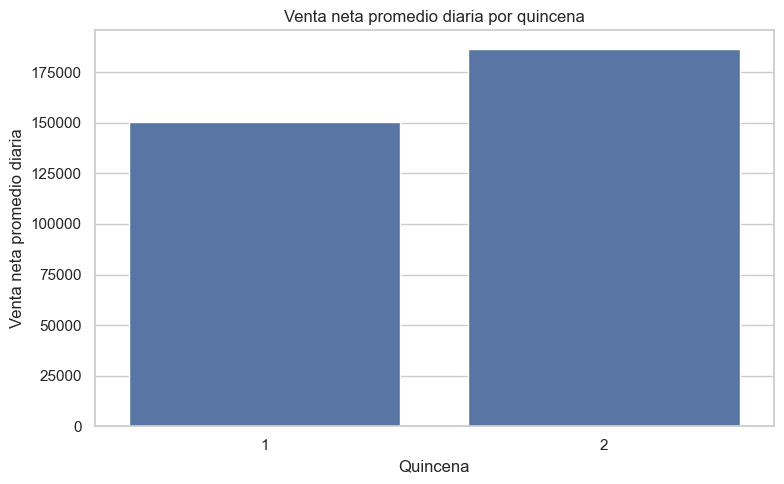

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\temporal\venta_promedio_por_quincena.png


In [24]:
# ===============================
# Venta neta promedio por quincena
# ===============================

plt.figure(figsize=(8, 5))

sns.barplot(
    data=resumen_quincena,
    x="QUINCENA",
    y="venta_neta_promedio_dia"
)

plt.title("Venta neta promedio diaria por quincena")
plt.xlabel("Quincena")
plt.ylabel("Venta neta promedio diaria")
plt.tight_layout()

output_fig = TEMPORAL_FIGURES_DIR / "venta_promedio_por_quincena.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

## Venta neta promedio diaria por quincena

La gráfica compara la `VENTA_NETA` promedio diaria entre la primera y la segunda quincena del mes.

Se observa que la **segunda quincena** presenta un promedio diario claramente superior al de la primera quincena. Esto confirma que la mayor venta de la segunda mitad del mes no se debe únicamente a que tenga más días acumulados, sino a que en promedio se vende más por día.

Este comportamiento puede estar relacionado con dinámicas comerciales propias del calendario mensual, como pagos de nómina, mayor actividad de consumo hacia finales de mes, promociones específicas o compras de reposición.

En conclusión, la variable `QUINCENA` tiene valor analítico porque permite capturar diferencias dentro del mes. Para futuros modelos predictivos, incluir esta variable puede ayudar a explicar cambios en el nivel de ventas según el momento del mes.

In [25]:
# ===============================
# Fin de semana vs días hábiles
# ===============================

resumen_fin_semana = (
    df.groupby("FIN_SEMANA")
    .agg(
        filas=("NroReg", "count"),
        dias=("FECHA", "nunique"),
        venta_bruta=("VENTA", "sum"),
        descuento=("DESCUENTO", "sum"),
        venta_neta=("VENTA_NETA", "sum"),
        unidades=("CANT", "sum"),
        tickets=("TICKET_ID", "nunique"),
        lineas_promo=("PROMO_FLAG", "sum")
    )
    .reset_index()
)

resumen_fin_semana["tipo_dia"] = resumen_fin_semana["FIN_SEMANA"].map({
    False: "Día hábil",
    True: "Fin de semana"
})

resumen_fin_semana["venta_neta_promedio_dia"] = resumen_fin_semana["venta_neta"] / resumen_fin_semana["dias"]

resumen_fin_semana["ticket_promedio_neto"] = np.where(
    resumen_fin_semana["tickets"] > 0,
    resumen_fin_semana["venta_neta"] / resumen_fin_semana["tickets"],
    np.nan
)

resumen_fin_semana

,FIN_SEMANA,filas,dias,venta_bruta,descuento,venta_neta,unidades,tickets,lineas_promo,tipo_dia,venta_neta_promedio_dia,ticket_promedio_neto
0,False,309566,522,"107,268,092.00","13,610,298.00","93,657,794.00","359,164.42",204903,92467,Día hábil,"179,421.06",457.08
1,True,100194,209,"32,194,406.00","2,659,838.00","29,534,568.00","135,808.81",72086,16772,Fin de semana,"141,313.72",409.71


## Comparación entre días hábiles y fines de semana

La tabla compara el comportamiento comercial entre los **días hábiles** y los **fines de semana**.

Los días hábiles concentran la mayor parte de la actividad, con **309.566 filas**, **204.903 tickets** y una venta neta total de **93.657.794**. Esto es esperable porque hay más días hábiles en el periodo analizado, con **522 días** frente a **209 días de fin de semana**.

Sin embargo, al revisar la `VENTA_NETA` promedio diaria, también se observa que los días hábiles tienen mejor desempeño: **179.421,06** frente a **141.313,72** en fines de semana. Esto indica que la diferencia no se explica únicamente por la cantidad de días, sino también por un mayor nivel promedio de ventas en días hábiles.

El ticket promedio neto también es mayor en días hábiles, con **457,08**, mientras que en fines de semana es de **409,71**. Esto sugiere que, en promedio, las compras realizadas entre semana tienen mayor valor por ticket.

Aunque los fines de semana concentran menos venta neta total y menor ticket promedio, siguen representando una parte importante de la operación, con **72.086 tickets** y más de **29,5 millones** en venta neta.

En conclusión, la variable `FIN_SEMANA` es relevante para el análisis temporal. Los días hábiles presentan mayor venta promedio diaria y mayor ticket promedio neto, por lo que esta diferencia debe considerarse en análisis posteriores y en futuros modelos predictivos.

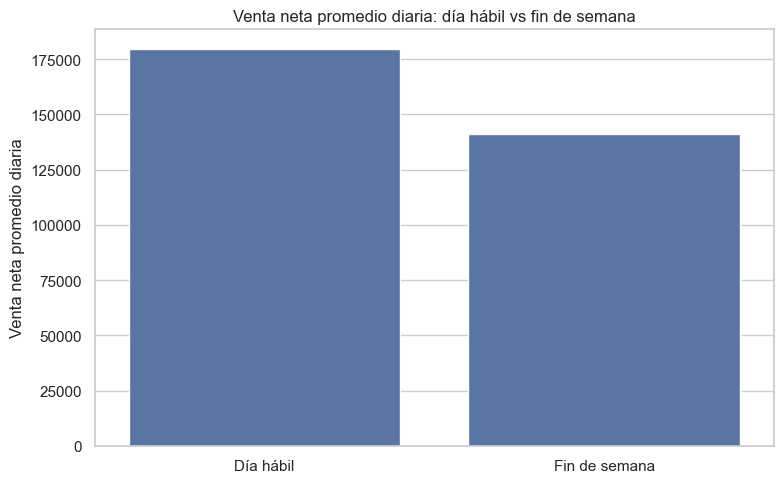

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\temporal\venta_promedio_fin_semana_vs_habil.png


In [26]:
# ===============================
# Venta promedio día hábil vs fin de semana
# ===============================

plt.figure(figsize=(8, 5))

sns.barplot(
    data=resumen_fin_semana,
    x="tipo_dia",
    y="venta_neta_promedio_dia"
)

plt.title("Venta neta promedio diaria: día hábil vs fin de semana")
plt.xlabel("")
plt.ylabel("Venta neta promedio diaria")
plt.tight_layout()

output_fig = TEMPORAL_FIGURES_DIR / "venta_promedio_fin_semana_vs_habil.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

## Venta neta promedio diaria: día hábil vs fin de semana

La gráfica compara la `VENTA_NETA` promedio diaria entre días hábiles y fines de semana.

Se observa que los **días hábiles** presentan una venta neta promedio diaria mayor que los **fines de semana**. Esto confirma que, en promedio, la operación comercial genera más venta durante la semana que los sábados y domingos.

Este resultado coincide con el análisis por día de la semana, donde el viernes mostró el mayor desempeño y el domingo el menor. Por tanto, la diferencia entre día hábil y fin de semana no solo está relacionada con la cantidad de días, sino también con el comportamiento promedio de compra.

La menor venta promedio en fines de semana puede estar asociada a cambios en el tráfico de clientes, hábitos de consumo, horarios de operación, menor intensidad promocional o diferencias en la composición de productos vendidos.

En conclusión, `FIN_SEMANA` es una variable relevante para explicar la variación temporal de las ventas. Para futuros modelos predictivos, conviene incluir esta variable junto con el día de la semana, mes, quincena y variables promocionales.

In [27]:
# ===============================
# Fin de mes vs resto del mes
# ===============================

resumen_fin_mes = (
    df.groupby("FIN_MES")
    .agg(
        filas=("NroReg", "count"),
        dias=("FECHA", "nunique"),
        venta_bruta=("VENTA", "sum"),
        descuento=("DESCUENTO", "sum"),
        venta_neta=("VENTA_NETA", "sum"),
        unidades=("CANT", "sum"),
        tickets=("TICKET_ID", "nunique"),
        lineas_promo=("PROMO_FLAG", "sum")
    )
    .reset_index()
)

resumen_fin_mes["tipo_dia"] = resumen_fin_mes["FIN_MES"].map({
    False: "Resto del mes",
    True: "Fin de mes"
})

resumen_fin_mes["venta_neta_promedio_dia"] = resumen_fin_mes["venta_neta"] / resumen_fin_mes["dias"]

resumen_fin_mes["ticket_promedio_neto"] = np.where(
    resumen_fin_mes["tickets"] > 0,
    resumen_fin_mes["venta_neta"] / resumen_fin_mes["tickets"],
    np.nan
)

resumen_fin_mes

,FIN_MES,filas,dias,venta_bruta,descuento,venta_neta,unidades,tickets,lineas_promo,tipo_dia,venta_neta_promedio_dia,ticket_promedio_neto
0,False,370483,707,"121,805,276.00","11,702,677.00","110,102,599.00","447,918.27",259040,82734,Resto del mes,"155,732.11",425.04
1,True,39277,24,"17,657,222.00","4,567,459.00","13,089,763.00","47,054.96",17949,26505,Fin de mes,"545,406.79",729.28


## Comparación entre fin de mes y resto del mes

La tabla compara el comportamiento de las ventas entre los días marcados como **fin de mes** y el resto de días del periodo.

Aunque los días de fin de mes son muchos menos, solo **24 días** frente a **707 días** del resto del mes, presentan una venta neta promedio diaria mucho más alta. En los días de fin de mes, la venta neta promedio diaria es de **545.406,79**, mientras que en el resto del mes es de **155.732,11**.

También se observa que el `ticket_promedio_neto` es considerablemente mayor en fin de mes, con **729,28**, frente a **425,04** en el resto del mes. Esto indica que no solo se vende más en total durante esos días, sino que el valor promedio por ticket también aumenta.

Los días de fin de mes concentran **26.505 líneas promocionales**, una cifra muy alta considerando que solo corresponden a 24 días. Esto sugiere que los cierres de mes pueden estar asociados a campañas promocionales, mayor actividad comercial, compras de mayor valor o comportamientos operativos particulares.

En conclusión, el fin de mes tiene un efecto muy fuerte sobre las ventas. La variable `FIN_MES` debe considerarse clave dentro del análisis temporal y en futuros modelos predictivos, ya que captura días con un comportamiento comercial claramente diferente al resto del mes.

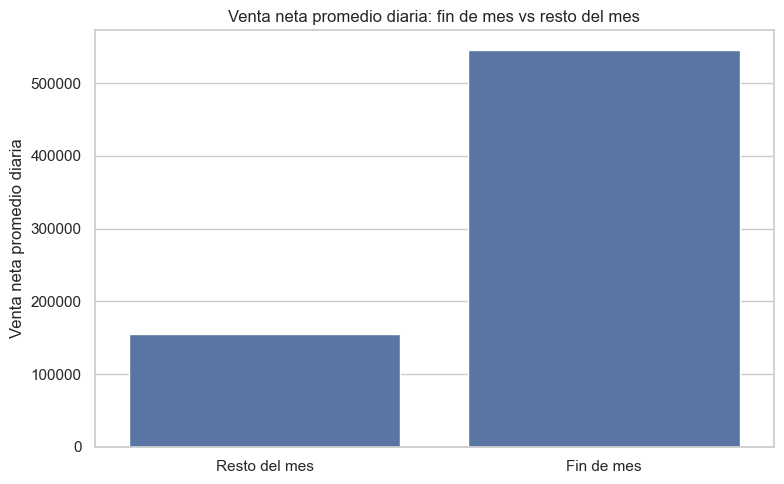

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\temporal\venta_promedio_fin_mes_vs_resto.png


In [28]:
# ===============================
# Venta promedio fin de mes vs resto del mes
# ===============================

plt.figure(figsize=(8, 5))

sns.barplot(
    data=resumen_fin_mes,
    x="tipo_dia",
    y="venta_neta_promedio_dia"
)

plt.title("Venta neta promedio diaria: fin de mes vs resto del mes")
plt.xlabel("")
plt.ylabel("Venta neta promedio diaria")
plt.tight_layout()

output_fig = TEMPORAL_FIGURES_DIR / "venta_promedio_fin_mes_vs_resto.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

## Venta neta promedio diaria: fin de mes vs resto del mes

La gráfica compara la `VENTA_NETA` promedio diaria entre los días de **fin de mes** y el **resto del mes**.

Se observa una diferencia muy marcada: los días de **fin de mes** presentan una venta neta promedio diaria mucho mayor que los demás días. Esto confirma que el cierre de mes tiene un comportamiento comercial especial dentro de la base.

Este resultado coincide con la tabla anterior, donde los días de fin de mes mostraban mayor venta promedio diaria y mayor ticket promedio neto. Además, estos días concentran una cantidad importante de líneas promocionales, lo que puede estar relacionado con campañas, cierres comerciales, promociones específicas o dinámicas operativas de fin de periodo.

En conclusión, `FIN_MES` es una variable altamente relevante para explicar cambios en la venta neta. Para futuros modelos predictivos, esta variable debería incluirse porque captura días con un comportamiento claramente distinto al resto del mes.

In [29]:
# ===============================
# Top días con mayor venta neta
# ===============================

top_dias_venta = (
    ventas_diarias
    .sort_values("venta_neta", ascending=False)
    .head(20)
    .copy()
)

top_dias_venta

,FECHA,filas,venta_bruta,descuento,venta_neta,unidades,tickets,productos,pdv,lineas_promo,registros_validos,descuento_pct,ticket_promedio_neto,unidades_por_ticket,promo_pct_lineas,venta_neta_rolling_7d,venta_neta_rolling_30d
89,2023-03-31,2803,"1,403,638.00","418,265.00","985,373.00","3,722.57",1182,1316,3,2124,2630,29.80,833.65,3.15,75.78,"241,818.00","189,996.83"
150,2023-05-31,2597,"1,252,438.00","373,578.00","878,860.00","3,890.00",1090,1218,3,2040,2478,29.83,806.29,3.57,78.55,"232,552.14","182,458.90"
303,2023-10-31,2492,"1,263,378.00","413,990.00","849,388.00","2,775.78",975,1180,3,1946,2379,32.77,871.17,2.85,78.09,"251,101.29","180,375.07"
242,2023-08-31,2509,"1,233,572.00","397,812.00","835,760.00","2,748.81",1026,1143,3,1926,2361,32.25,814.58,2.68,76.76,"230,639.57","174,465.87"
333,2023-11-30,2142,"1,066,861.00","252,030.00","814,831.00","2,459.74",884,1038,3,1516,2020,23.62,921.75,2.78,70.77,"232,277.00","179,998.87"
30,2023-01-31,2576,"1,180,602.00","368,333.00","812,269.00","2,891.25",1031,1198,3,2038,2463,31.20,787.85,2.80,79.11,"250,484.14","179,920.20"
180,2023-06-30,2661,"1,155,900.00","365,658.00","790,242.00","2,949.93",1143,1221,3,2011,2520,31.63,691.38,2.58,75.57,"226,660.43","179,208.93"
58,2023-02-28,2171,"973,403.00","241,293.00","732,110.00","2,320.39",936,1077,3,1727,2098,24.79,782.17,2.48,79.55,"232,729.57","217,976.77"
395,2024-01-31,2248,"986,675.00","283,473.00","703,202.00","2,380.10",974,1115,3,1633,2162,28.73,721.97,2.44,72.64,"217,088.43","171,477.27"
424,2024-02-29,1759,"842,923.00","158,519.00","684,404.00","2,745.99",753,923,3,1213,1674,18.81,908.90,3.65,68.96,"201,499.43","205,837.83"


## Días con mayor venta neta

La tabla muestra los días con mayor `VENTA_NETA` dentro del periodo analizado. Se observa que varios de los días con ventas más altas corresponden a **cierres de mes**, como el 31 de marzo, 31 de mayo, 31 de octubre, 31 de agosto, 30 de noviembre, 31 de enero, 30 de junio, 28 de febrero y 31 de julio.

Este resultado confirma el hallazgo anterior: los días de fin de mes tienen un comportamiento comercial muy superior al resto de días. En estos registros se observan ventas netas altas, mayor número de filas, más tickets, más productos y una alta participación de líneas promocionales.

Por ejemplo, el **31 de marzo de 2023** registra una venta neta de **985.373**, con **2.803 líneas**, **1.182 tickets**, **1.316 productos** y un porcentaje de líneas promocionales de **75,78%**. Esto muestra que los días de mayor venta no solo tienen más transacciones, sino también una fuerte intensidad promocional.

También se observa que varios días con alta venta tienen porcentajes de descuento elevados, en algunos casos superiores al **25%** o **30%**. Esto sugiere que las promociones y descuentos pueden estar impulsando de manera importante los picos de venta.

Además, algunos días que no son estrictamente fin de mes, como el **15 de diciembre de 2023**, también aparecen entre los días de mayor venta, posiblemente por campañas de temporada o comportamiento comercial asociado al cierre de año.

En conclusión, los días con mayor venta neta parecen estar fuertemente relacionados con cierres de mes, promociones y eventos comerciales específicos. Para futuros modelos predictivos, variables como `FIN_MES`, `promo_pct_lineas`, `descuento_pct`, mes y temporada de fin de año serán especialmente importantes.

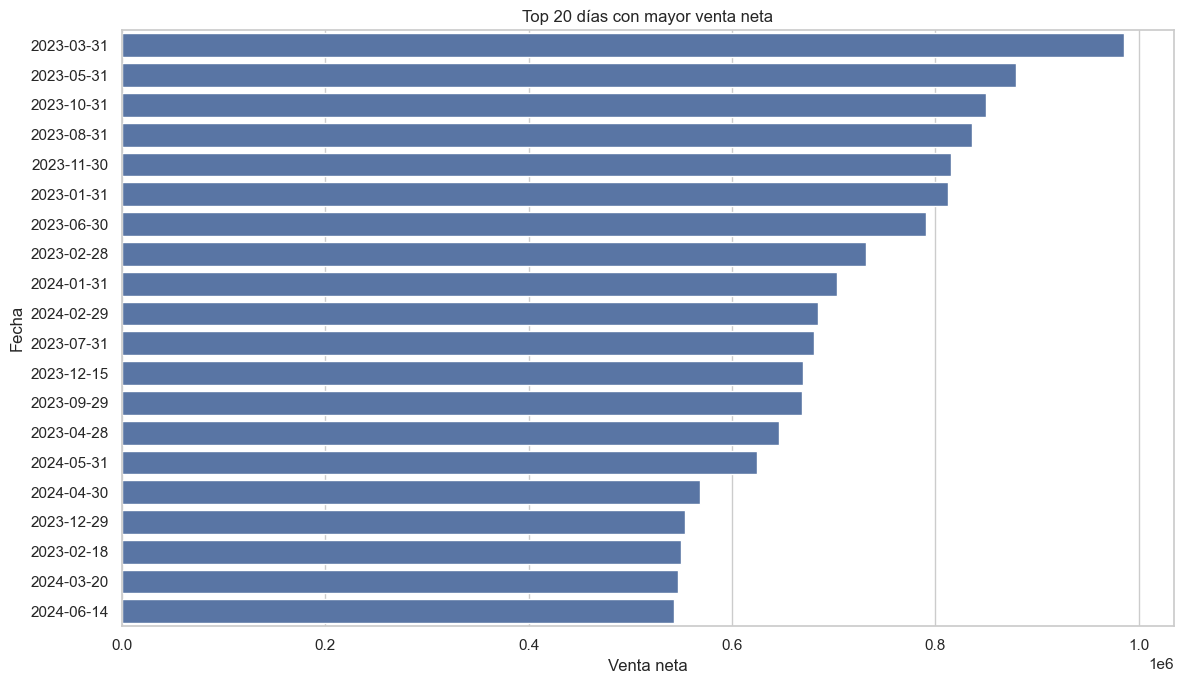

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\temporal\top_20_dias_mayor_venta.png


In [30]:
# ===============================
# Gráfico top días con mayor venta neta
# ===============================

top_dias_venta_plot = top_dias_venta.copy()
top_dias_venta_plot["FECHA_STR"] = top_dias_venta_plot["FECHA"].dt.strftime("%Y-%m-%d")

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_dias_venta_plot,
    y="FECHA_STR",
    x="venta_neta"
)

plt.title("Top 20 días con mayor venta neta")
plt.xlabel("Venta neta")
plt.ylabel("Fecha")
plt.tight_layout()

output_fig = TEMPORAL_FIGURES_DIR / "top_20_dias_mayor_venta.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

## Top 20 días con mayor venta neta

La gráfica presenta los **20 días con mayor `VENTA_NETA`** dentro del periodo analizado. Se observa que la mayoría de estos días corresponden a fechas cercanas o iguales a **fin de mes**, especialmente el último día calendario de varios meses.

El día con mayor venta neta fue el **31 de marzo de 2023**, seguido por fechas como **31 de mayo de 2023**, **31 de octubre de 2023**, **31 de agosto de 2023**, **30 de noviembre de 2023** y **31 de enero de 2023**. Esto confirma que los cierres de mes tienen un comportamiento comercial muy fuerte dentro de la base.

También aparecen algunos días que no son estrictamente fin de mes, como **15 de diciembre de 2023**, **18 de febrero de 2023**, **20 de marzo de 2024** y **14 de junio de 2024**. Estos casos pueden estar asociados a eventos comerciales, promociones puntuales, ventas atípicas o tickets de alto valor.

El predominio de fechas de 2023 dentro del top también coincide con el análisis anual, donde 2023 presentó mayor venta neta total que 2024.

En conclusión, los días de mayor venta neta no parecen distribuirse de manera aleatoria, sino que se relacionan principalmente con cierres de mes y eventos comerciales específicos. Por eso, variables como `FIN_MES`, `MES`, `PROMO_FLAG`, `descuento_pct` y `promo_pct_lineas` son importantes para explicar los picos de venta.

In [31]:
# ===============================
# Días con menor venta neta
# ===============================

bottom_dias_venta = (
    ventas_diarias
    .sort_values("venta_neta", ascending=True)
    .head(20)
    .copy()
)

bottom_dias_venta

,FECHA,filas,venta_bruta,descuento,venta_neta,unidades,tickets,productos,pdv,lineas_promo,registros_validos,descuento_pct,ticket_promedio_neto,unidades_por_ticket,promo_pct_lineas,venta_neta_rolling_7d,venta_neta_rolling_30d
301,2023-10-29,183,"44,922.00","1,242.00","43,680.00",184.58,139,157,3,15,180,2.76,314.24,1.33,8.20,"164,198.86","158,391.77"
680,2024-11-11,206,"47,032.00","1,460.00","45,572.00",214.05,155,152,3,22,202,3.10,294.01,1.38,10.68,"104,368.43","117,717.27"
673,2024-11-04,207,"57,483.00","1,352.00","56,131.00",217.99,157,146,3,16,205,2.35,357.52,1.39,7.73,"141,266.86","117,762.77"
652,2024-10-14,239,"58,924.00","1,889.00","57,035.00",251.23,181,165,3,25,234,3.21,315.11,1.39,10.46,"100,718.14","125,365.07"
511,2024-05-26,249,"63,886.00","5,374.00","58,512.00",297.73,185,166,3,34,243,8.41,316.28,1.61,13.65,"139,895.14","142,382.20"
658,2024-10-20,215,"62,166.00","2,569.00","59,597.00",248.10,158,154,3,39,211,4.13,377.20,1.57,18.14,"140,258.14","121,977.03"
630,2024-09-22,227,"63,248.00","2,865.00","60,383.00",265.93,173,154,3,36,226,4.53,349.03,1.54,15.86,"166,361.71","134,878.30"
660,2024-10-22,244,"64,353.00","3,315.00","61,038.00",223.19,196,188,3,41,242,5.15,311.42,1.14,16.80,"122,155.71","119,228.13"
588,2024-08-11,246,"67,527.00","4,307.00","63,220.00",275.99,187,172,3,35,244,6.38,338.07,1.48,14.23,"105,415.14","135,372.33"
646,2024-10-08,259,"64,587.00","1,264.00","63,323.00",255.11,206,199,3,17,257,1.96,307.39,1.24,6.56,"102,551.86","127,197.07"


## Días con menor venta neta

La tabla muestra los días con menor `VENTA_NETA` dentro del periodo analizado. En general, estos días presentan un bajo número de filas, tickets, productos vendidos y unidades, lo que explica su menor nivel de venta.

Se observa que varios de los días con menor venta neta corresponden a **domingos o días de baja actividad**, como el 29 de octubre de 2023, el 26 de mayo de 2024, el 20 de octubre de 2024, el 22 de septiembre de 2024 y el 11 de agosto de 2024. Esto coincide con el análisis por día de la semana, donde el domingo mostró el menor desempeño promedio.

También se evidencia que muchos de estos días pertenecen a **2024**, especialmente entre julio, agosto, octubre y noviembre. Esto refuerza el hallazgo de que 2024 tuvo un comportamiento comercial más débil frente a 2023, principalmente durante el segundo semestre.

A diferencia de los días con mayor venta neta, estos días presentan porcentajes de promoción relativamente bajos o moderados. Por ejemplo, algunos registros tienen `promo_pct_lineas` por debajo del 10% o cerca del 15%, lo que sugiere menor intensidad promocional.

El `ticket_promedio_neto` también tiende a ser menor en varios de estos días, aunque existen excepciones. Por tanto, la baja venta diaria parece explicarse principalmente por una menor cantidad de tickets y menor volumen de líneas, más que únicamente por el valor promedio de cada compra.

En conclusión, los días de menor venta neta están asociados con baja actividad transaccional, menor número de tickets, menor intensidad promocional y presencia importante de fechas de 2024. Estos casos son útiles para entender los valles de la serie temporal y deben considerarse al construir variables predictivas como día de semana, fin de semana, promociones y tendencia reciente.

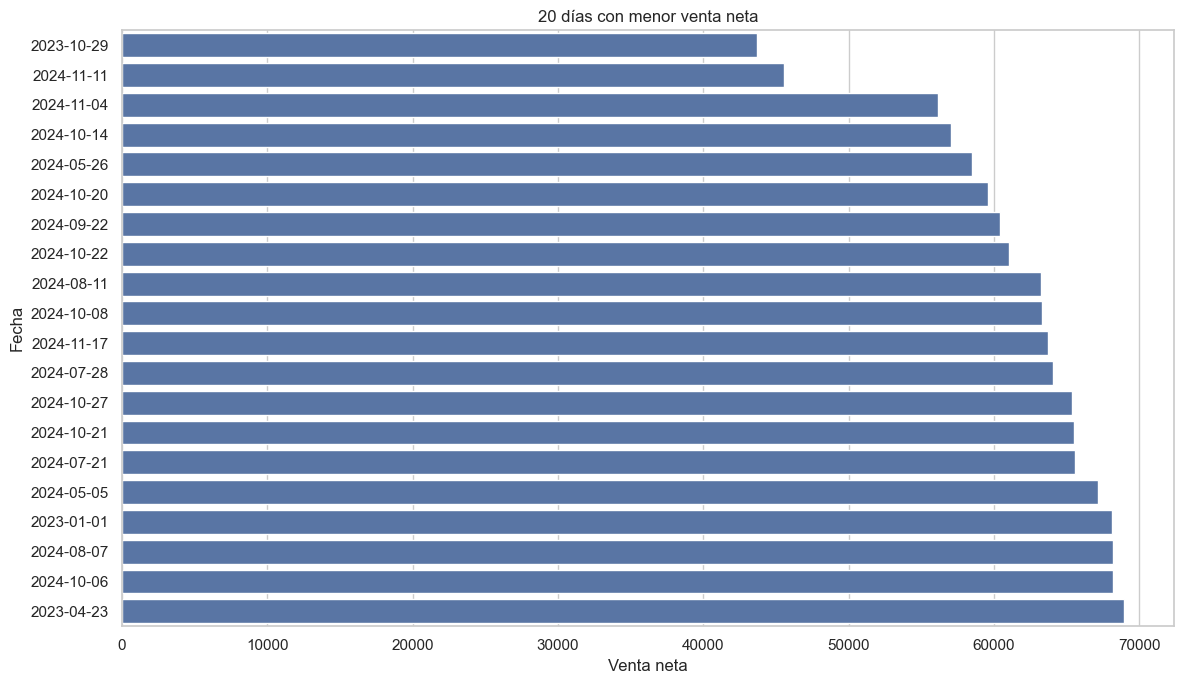

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\temporal\bottom_20_dias_menor_venta.png


In [32]:
# ===============================
# Gráfico días con menor venta neta
# ===============================

bottom_dias_venta_plot = bottom_dias_venta.copy()
bottom_dias_venta_plot["FECHA_STR"] = bottom_dias_venta_plot["FECHA"].dt.strftime("%Y-%m-%d")

plt.figure(figsize=(12, 7))

sns.barplot(
    data=bottom_dias_venta_plot,
    y="FECHA_STR",
    x="venta_neta"
)

plt.title("20 días con menor venta neta")
plt.xlabel("Venta neta")
plt.ylabel("Fecha")
plt.tight_layout()

output_fig = TEMPORAL_FIGURES_DIR / "bottom_20_dias_menor_venta.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

## Días con menor venta neta

La gráfica muestra los **20 días con menor `VENTA_NETA`** dentro del periodo analizado. Estos días presentan valores de venta neta relativamente bajos, ubicados aproximadamente entre **43.000 y 69.000**.

El día con menor venta neta fue el **29 de octubre de 2023**, seguido por fechas como **11 de noviembre de 2024**, **4 de noviembre de 2024**, **14 de octubre de 2024** y **26 de mayo de 2024**.

Un aspecto importante es que la mayoría de los días con menor venta neta pertenecen a **2024**, especialmente a los meses de julio, agosto, octubre y noviembre. Esto coincide con los análisis anteriores, donde se evidenció que 2024 tuvo un desempeño inferior frente a 2023, principalmente durante el segundo semestre.

También se observa presencia de varios domingos o días asociados a menor actividad comercial, lo cual es consistente con el análisis por día de la semana, donde el domingo presentó la menor venta promedio diaria.

En conclusión, los días de menor venta neta parecen estar relacionados con menor actividad transaccional, baja cantidad de tickets, menor intensidad promocional y el comportamiento más débil observado en 2024. Estos días son importantes para entender los valles de la serie temporal y deben considerarse en futuros análisis de estacionalidad y modelado predictivo.

In [33]:
# ===============================
# Detección de días atípicos por IQR
# ===============================

q1 = ventas_diarias["venta_neta"].quantile(0.25)
q3 = ventas_diarias["venta_neta"].quantile(0.75)
iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

ventas_diarias["FLAG_DIA_ATIPICO_BAJO"] = ventas_diarias["venta_neta"] < limite_inferior
ventas_diarias["FLAG_DIA_ATIPICO_ALTO"] = ventas_diarias["venta_neta"] > limite_superior
ventas_diarias["FLAG_DIA_ATIPICO"] = (
    ventas_diarias["FLAG_DIA_ATIPICO_BAJO"] | 
    ventas_diarias["FLAG_DIA_ATIPICO_ALTO"]
)

dias_atipicos = ventas_diarias[ventas_diarias["FLAG_DIA_ATIPICO"]].copy()

print(f"Q1: {q1:,.2f}")
print(f"Q3: {q3:,.2f}")
print(f"IQR: {iqr:,.2f}")
print(f"Límite inferior: {limite_inferior:,.2f}")
print(f"Límite superior: {limite_superior:,.2f}")
print(f"Días atípicos detectados: {len(dias_atipicos):,}")

dias_atipicos.sort_values("venta_neta", ascending=False)

Q1: 103,913.50
Q3: 179,197.50
IQR: 75,284.00
Límite inferior: -9,012.50
Límite superior: 292,123.50
Días atípicos detectados: 74


,FECHA,filas,venta_bruta,descuento,venta_neta,unidades,tickets,productos,pdv,lineas_promo,registros_validos,descuento_pct,ticket_promedio_neto,unidades_por_ticket,promo_pct_lineas,venta_neta_rolling_7d,venta_neta_rolling_30d,FLAG_DIA_ATIPICO_BAJO,FLAG_DIA_ATIPICO_ALTO,FLAG_DIA_ATIPICO
89,2023-03-31,2803,"1,403,638.00","418,265.00","985,373.00","3,722.57",1182,1316,3,2124,2630,29.80,833.65,3.15,75.78,"241,818.00","189,996.83",False,True,True
150,2023-05-31,2597,"1,252,438.00","373,578.00","878,860.00","3,890.00",1090,1218,3,2040,2478,29.83,806.29,3.57,78.55,"232,552.14","182,458.90",False,True,True
303,2023-10-31,2492,"1,263,378.00","413,990.00","849,388.00","2,775.78",975,1180,3,1946,2379,32.77,871.17,2.85,78.09,"251,101.29","180,375.07",False,True,True
242,2023-08-31,2509,"1,233,572.00","397,812.00","835,760.00","2,748.81",1026,1143,3,1926,2361,32.25,814.58,2.68,76.76,"230,639.57","174,465.87",False,True,True
333,2023-11-30,2142,"1,066,861.00","252,030.00","814,831.00","2,459.74",884,1038,3,1516,2020,23.62,921.75,2.78,70.77,"232,277.00","179,998.87",False,True,True
30,2023-01-31,2576,"1,180,602.00","368,333.00","812,269.00","2,891.25",1031,1198,3,2038,2463,31.20,787.85,2.80,79.11,"250,484.14","179,920.20",False,True,True
180,2023-06-30,2661,"1,155,900.00","365,658.00","790,242.00","2,949.93",1143,1221,3,2011,2520,31.63,691.38,2.58,75.57,"226,660.43","179,208.93",False,True,True
58,2023-02-28,2171,"973,403.00","241,293.00","732,110.00","2,320.39",936,1077,3,1727,2098,24.79,782.17,2.48,79.55,"232,729.57","217,976.77",False,True,True
395,2024-01-31,2248,"986,675.00","283,473.00","703,202.00","2,380.10",974,1115,3,1633,2162,28.73,721.97,2.44,72.64,"217,088.43","171,477.27",False,True,True
424,2024-02-29,1759,"842,923.00","158,519.00","684,404.00","2,745.99",753,923,3,1213,1674,18.81,908.90,3.65,68.96,"201,499.43","205,837.83",False,True,True


## Detección de días atípicos en venta neta diaria

Se aplicó el método del rango intercuartílico, conocido como IQR, para identificar días atípicos en la `VENTA_NETA` diaria.

El primer cuartil, `Q1`, fue de **103.913,50**, mientras que el tercer cuartil, `Q3`, fue de **179.197,50**. A partir de estos valores se obtuvo un `IQR` de **75.284,00**, que representa la dispersión central de la venta neta diaria.

Con este método se definió un límite inferior de **-9.012,50** y un límite superior de **292.123,50**. Como el límite inferior es negativo y la venta neta diaria normalmente se mantiene por encima de cero, los días atípicos detectados corresponden principalmente a días con ventas inusualmente altas.

En total se identificaron **74 días atípicos**, es decir, días donde la venta neta diaria supera el comportamiento esperado según la distribución general de la serie.

Este resultado es coherente con los análisis anteriores, donde se observaron picos importantes en fechas de fin de mes, cierres comerciales, promociones fuertes y algunos días específicos de temporada. Por tanto, estos días no deben asumirse automáticamente como errores, sino como eventos comerciales especiales que deben analizarse de forma separada.

En conclusión, la detección de atípicos confirma que existen días con ventas netas extraordinariamente altas. Estos días deben conservarse marcados con banderas como `FLAG_DIA_ATIPICO_ALTO` y `FLAG_DIA_ATIPICO`, ya que pueden aportar información importante para entender picos de demanda, promociones y estacionalidad.

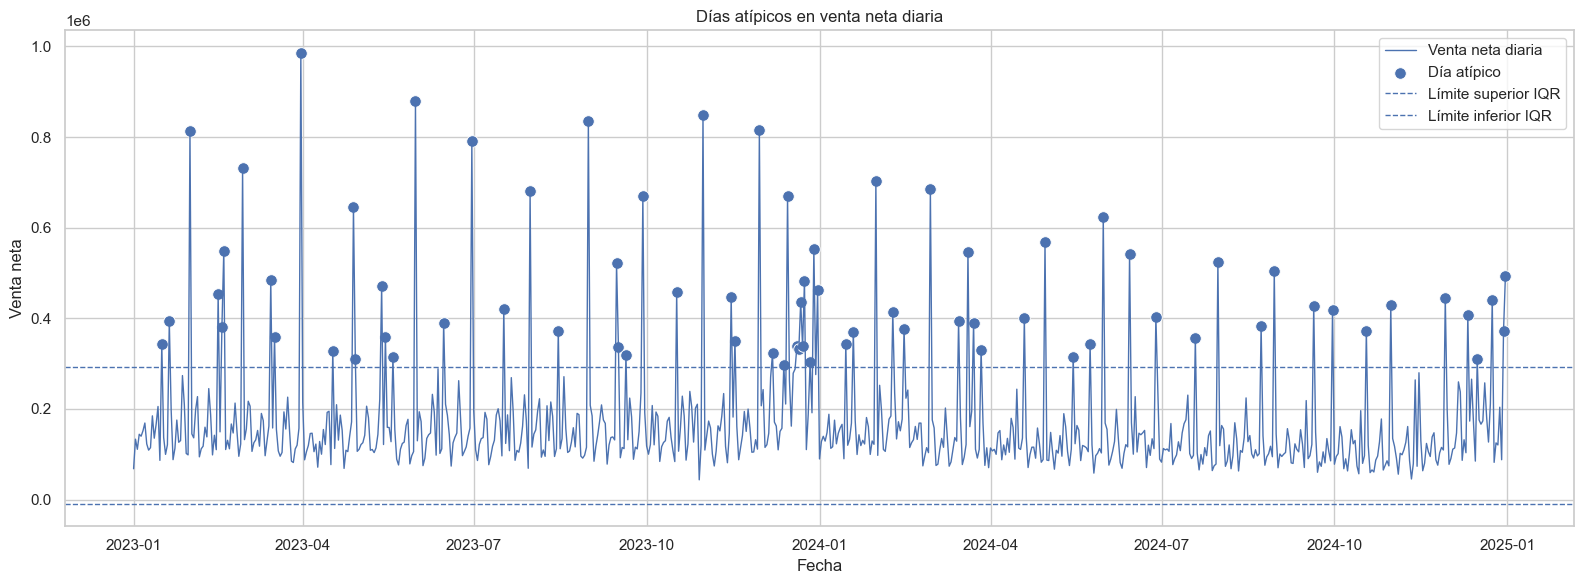

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\temporal\dias_atipicos_venta_neta_iqr.png


In [34]:
# ===============================
# Serie diaria con días atípicos
# ===============================

plt.figure(figsize=(16, 6))

sns.lineplot(
    data=ventas_diarias,
    x="FECHA",
    y="venta_neta",
    linewidth=1,
    label="Venta neta diaria"
)

sns.scatterplot(
    data=dias_atipicos,
    x="FECHA",
    y="venta_neta",
    s=70,
    label="Día atípico"
)

plt.axhline(limite_superior, linestyle="--", linewidth=1, label="Límite superior IQR")
plt.axhline(limite_inferior, linestyle="--", linewidth=1, label="Límite inferior IQR")

plt.title("Días atípicos en venta neta diaria")
plt.xlabel("Fecha")
plt.ylabel("Venta neta")
plt.legend()
plt.tight_layout()

output_fig = TEMPORAL_FIGURES_DIR / "dias_atipicos_venta_neta_iqr.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

## Visualización de días atípicos en venta neta diaria

La gráfica muestra la serie diaria de `VENTA_NETA` junto con los límites definidos mediante el método IQR para detectar días atípicos.

Se observa que la mayoría de los días se mantienen por debajo del límite superior de **292.123,50**, pero existen varios picos que superan ese umbral. Estos puntos fueron marcados como días atípicos altos, representados con puntos sobre la serie.

En total se detectaron **74 días atípicos**, todos asociados principalmente a ventas netas diarias inusualmente altas. No se observan días atípicos bajos relevantes, ya que el límite inferior calculado fue negativo y la venta neta diaria se mantiene por encima de ese valor.

Los picos atípicos aparecen en distintos momentos del periodo, especialmente durante 2023 y en algunos puntos de 2024. Muchos de estos días coinciden con cierres de mes, fechas promocionales o eventos comerciales específicos, lo cual refuerza la idea de que no necesariamente son errores, sino comportamientos especiales del negocio.

En conclusión, la gráfica confirma que la serie de ventas tiene días extraordinarios que deben analizarse de forma separada. Para futuros modelos predictivos, estos días pueden mantenerse identificados con la variable `FLAG_DIA_ATIPICO`, ya que pueden representar eventos comerciales importantes, promociones fuertes o patrones de estacionalidad.

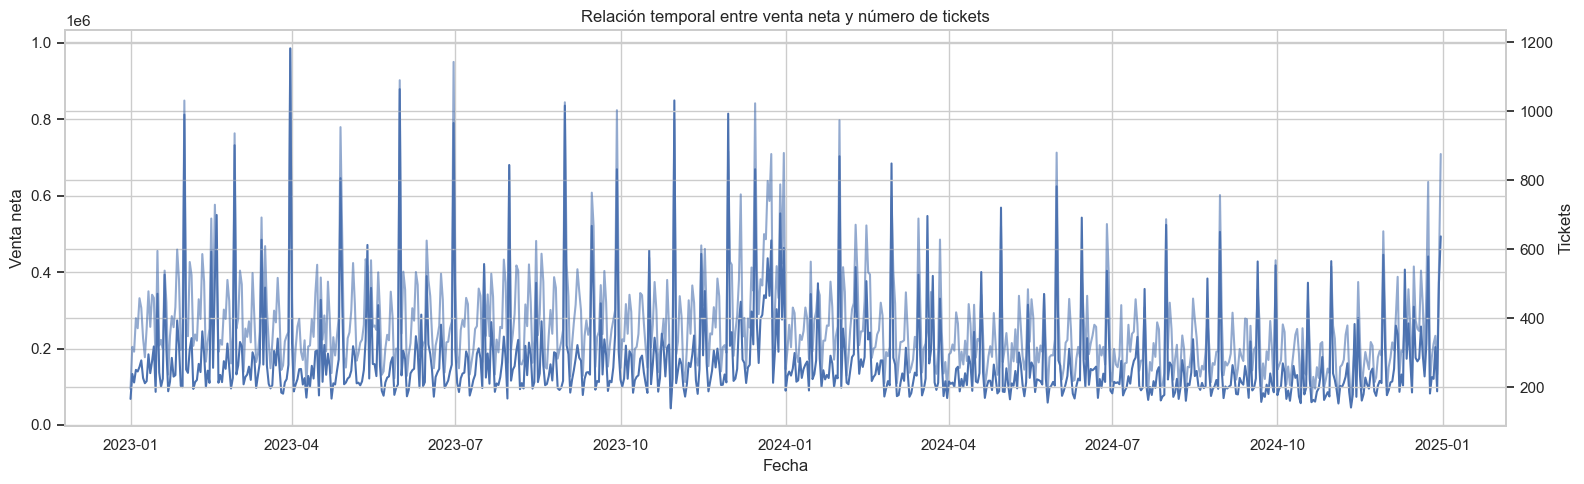

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\temporal\venta_neta_vs_tickets_diario.png


In [35]:
# ===============================
# Relación temporal entre venta, tickets y unidades
# ===============================

fig, ax1 = plt.subplots(figsize=(16, 5))

ax1.plot(
    ventas_diarias["FECHA"],
    ventas_diarias["venta_neta"],
    label="Venta neta"
)
ax1.set_xlabel("Fecha")
ax1.set_ylabel("Venta neta")

ax2 = ax1.twinx()
ax2.plot(
    ventas_diarias["FECHA"],
    ventas_diarias["tickets"],
    label="Tickets",
    alpha=0.6
)
ax2.set_ylabel("Tickets")

plt.title("Relación temporal entre venta neta y número de tickets")
fig.tight_layout()

output_fig = TEMPORAL_FIGURES_DIR / "venta_neta_vs_tickets_diario.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

## Relación temporal entre venta neta y número de tickets

La gráfica compara la evolución diaria de la `VENTA_NETA` con el número de `tickets` a lo largo del periodo analizado.

Se observa que ambas series tienen un comportamiento muy relacionado: cuando aumenta el número de tickets, generalmente también aumenta la venta neta diaria. Esto sugiere que gran parte de las variaciones en ventas están explicadas por cambios en el volumen de transacciones.

Los picos más altos de venta neta suelen coincidir con incrementos importantes en tickets, especialmente en fechas de alta actividad comercial, cierres de mes o eventos promocionales. Esto indica que los días de mayor venta no dependen únicamente de tickets de mayor valor, sino también de un mayor número de compras realizadas.

Durante 2023 se aprecian varios picos fuertes tanto en venta neta como en tickets. En 2024, la serie parece mostrar niveles más moderados durante buena parte del año, lo cual coincide con los análisis previos donde se identificó una reducción de ventas frente a 2023.

Hacia finales de 2024 se observa nuevamente una recuperación en ambas variables, posiblemente asociada a la estacionalidad de cierre de año.

En conclusión, existe una relación visual positiva entre el número de tickets y la venta neta diaria. Por tanto, `tickets` es una variable clave para explicar el comportamiento de las ventas y debe considerarse en los análisis posteriores, especialmente al estudiar ticket promedio, frecuencia de compra, promociones y posibles modelos predictivos.

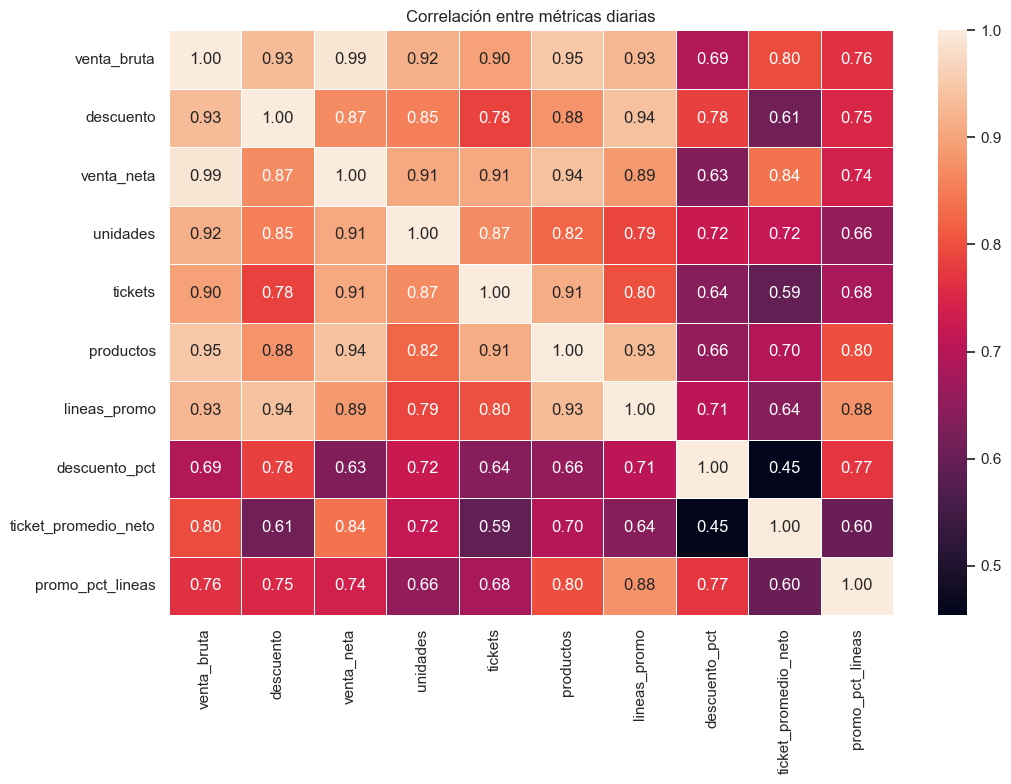

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\temporal\correlacion_metricas_diarias.png


In [36]:
# ===============================
# Correlaciones diarias
# ===============================

cols_correlacion_diaria = [
    "venta_bruta",
    "descuento",
    "venta_neta",
    "unidades",
    "tickets",
    "productos",
    "lineas_promo",
    "descuento_pct",
    "ticket_promedio_neto",
    "promo_pct_lineas"
]

correlacion_diaria = ventas_diarias[cols_correlacion_diaria].corr()

plt.figure(figsize=(11, 8))

sns.heatmap(
    correlacion_diaria,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlación entre métricas diarias")
plt.tight_layout()

output_fig = TEMPORAL_FIGURES_DIR / "correlacion_metricas_diarias.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

## Correlación entre métricas diarias

La matriz de correlación muestra la relación entre las principales métricas agregadas a nivel diario. En general, se observan correlaciones positivas altas entre las variables comerciales más importantes, lo que indica que cuando una métrica aumenta, las demás tienden a aumentar también.

La `venta_neta` tiene una correlación muy alta con la `venta_bruta` (**0,99**), lo cual es esperable porque la venta neta se calcula a partir de la venta bruta menos los descuentos. También presenta correlaciones fuertes con `productos` (**0,94**), `tickets` (**0,91**) y `unidades` (**0,91**). Esto sugiere que los días con mayor venta neta suelen estar asociados a más tickets, más unidades vendidas y mayor variedad de productos.

La variable `descuento` también se relaciona fuertemente con `venta_bruta` (**0,93**) y `lineas_promo` (**0,94**), lo que indica que los días con mayor actividad promocional tienden a concentrar mayores descuentos totales. Además, `lineas_promo` tiene una correlación alta con `promo_pct_lineas` (**0,88**), confirmando que el volumen promocional está relacionado con la proporción de líneas en promoción.

El `ticket_promedio_neto` presenta una correlación alta con `venta_neta` (**0,84**), pero más baja con `tickets` (**0,59**). Esto indica que la venta neta diaria no solo depende de cuántos tickets se generan, sino también del valor promedio de cada ticket.

Por otro lado, `descuento_pct` tiene correlaciones moderadas con las demás variables. Su relación con `ticket_promedio_neto` es la más baja de la matriz (**0,45**), lo que sugiere que un mayor porcentaje de descuento no necesariamente implica un ticket promedio más alto.

En conclusión, la venta neta diaria está fuertemente asociada con el volumen de operación: tickets, unidades, productos y venta bruta. Sin embargo, las variables promocionales también tienen un papel importante, especialmente en los días con mayor descuento y mayor proporción de líneas promocionales.

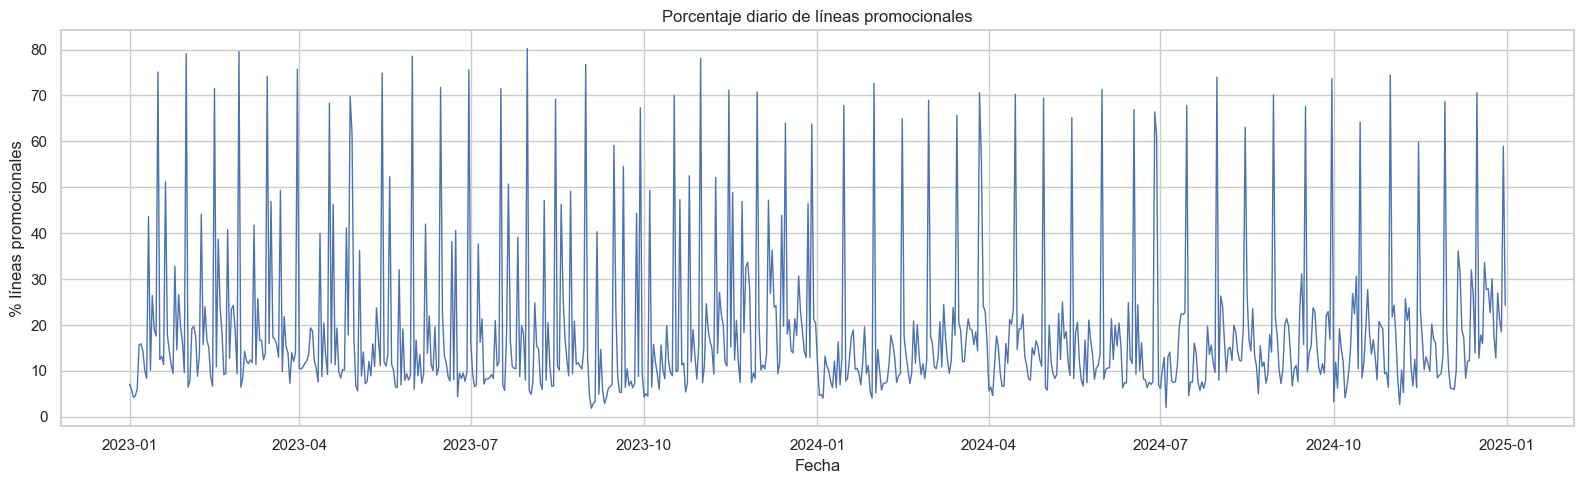

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\temporal\porcentaje_lineas_promocionales_diario.png


In [37]:
# ===============================
# Promociones en el tiempo
# ===============================

plt.figure(figsize=(16, 5))

sns.lineplot(
    data=ventas_diarias,
    x="FECHA",
    y="promo_pct_lineas",
    linewidth=1
)

plt.title("Porcentaje diario de líneas promocionales")
plt.xlabel("Fecha")
plt.ylabel("% líneas promocionales")
plt.tight_layout()

output_fig = TEMPORAL_FIGURES_DIR / "porcentaje_lineas_promocionales_diario.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

## Evolución diaria del porcentaje de líneas promocionales

La gráfica muestra el porcentaje diario de líneas promocionales durante el periodo analizado. Esta variable permite identificar qué proporción de las líneas de venta estuvo asociada a promociones, ofertas o descuentos cada día.

Se observa que la serie presenta alta variabilidad. La mayoría de los días se mantiene en niveles bajos o moderados, pero existen picos frecuentes donde el porcentaje de líneas promocionales supera el **60%** e incluso se acerca al **80%**.

Estos picos indican días con fuerte intensidad promocional, posiblemente asociados a campañas comerciales, cierres de mes, eventos especiales o estrategias puntuales de descuento. Este comportamiento coincide con análisis anteriores, donde varios días de alta venta neta también presentaban altos porcentajes de líneas promocionales.

Durante 2023 se observan varios picos fuertes de promoción, mientras que en 2024 la serie también mantiene eventos promocionales importantes, aunque con momentos de menor intensidad. Hacia finales de 2024 se aprecia un aumento en el porcentaje promocional, lo cual puede estar relacionado con la temporada de cierre de año.

En conclusión, la actividad promocional no es constante en el tiempo, sino que ocurre en días específicos con alta intensidad. Por esta razón, `promo_pct_lineas`, `PROMO_FLAG`, `TIPO_PROMO` y `descuento_pct` son variables importantes para explicar cambios en la venta neta y deben considerarse en futuros modelos predictivos.

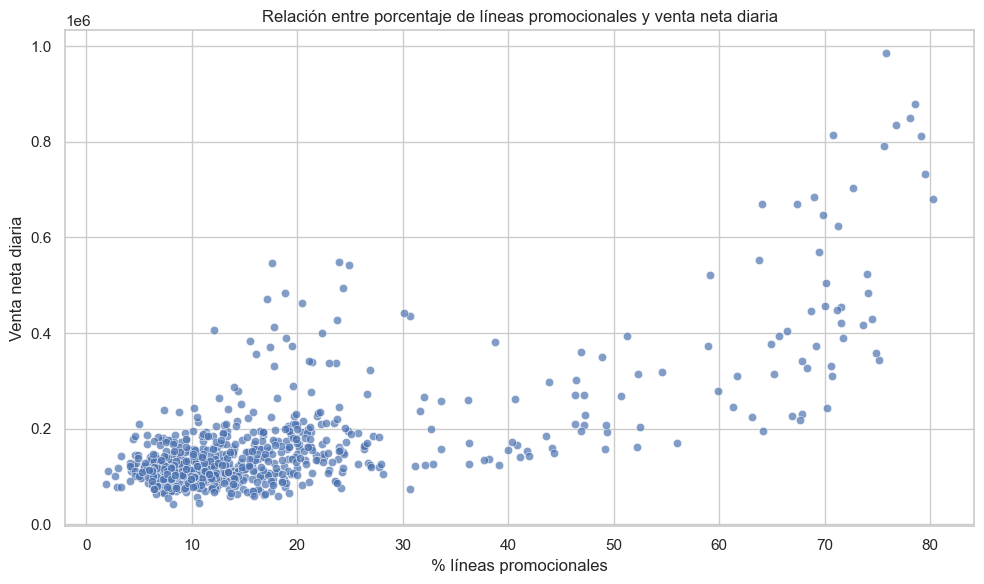

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\temporal\venta_neta_vs_promo_pct_diario.png


In [38]:
# ===============================
# Venta neta vs porcentaje de promoción
# ===============================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=ventas_diarias,
    x="promo_pct_lineas",
    y="venta_neta",
    alpha=0.7
)

plt.title("Relación entre porcentaje de líneas promocionales y venta neta diaria")
plt.xlabel("% líneas promocionales")
plt.ylabel("Venta neta diaria")
plt.tight_layout()

output_fig = TEMPORAL_FIGURES_DIR / "venta_neta_vs_promo_pct_diario.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

## Relación entre porcentaje de líneas promocionales y venta neta diaria

La gráfica muestra la relación entre el porcentaje diario de líneas promocionales y la `VENTA_NETA` diaria.

Se observa una relación positiva: a medida que aumenta el porcentaje de líneas promocionales, la venta neta diaria tiende a incrementarse. Esto indica que los días con mayor intensidad promocional suelen estar asociados con mayores niveles de venta.

La mayoría de los días se concentra en porcentajes promocionales bajos o moderados, aproximadamente entre **5% y 25%**, con ventas netas diarias generalmente por debajo de **250.000**. Esto representa el comportamiento más común de la operación.

Sin embargo, cuando el porcentaje de líneas promocionales supera aproximadamente el **60%**, aparecen varios días con ventas netas mucho más altas, incluso cercanas o superiores a **800.000**. Esto sugiere que los eventos promocionales fuertes pueden estar relacionados con picos importantes de venta.

También se observan algunos días con alto porcentaje promocional pero ventas no tan elevadas, lo que indica que la promoción por sí sola no explica completamente la venta neta. También influyen otros factores como el número de tickets, el tipo de productos vendidos, el PDV, el día de la semana, el mes y si corresponde a fin de mes.

En conclusión, la gráfica evidencia que la intensidad promocional tiene una relación importante con la venta neta diaria. Para futuros modelos predictivos, variables como `promo_pct_lineas`, `lineas_promo`, `descuento_pct`, `FIN_MES`, `DIA_SEMANA` y `tickets` deben considerarse como posibles explicativas del comportamiento de las ventas.

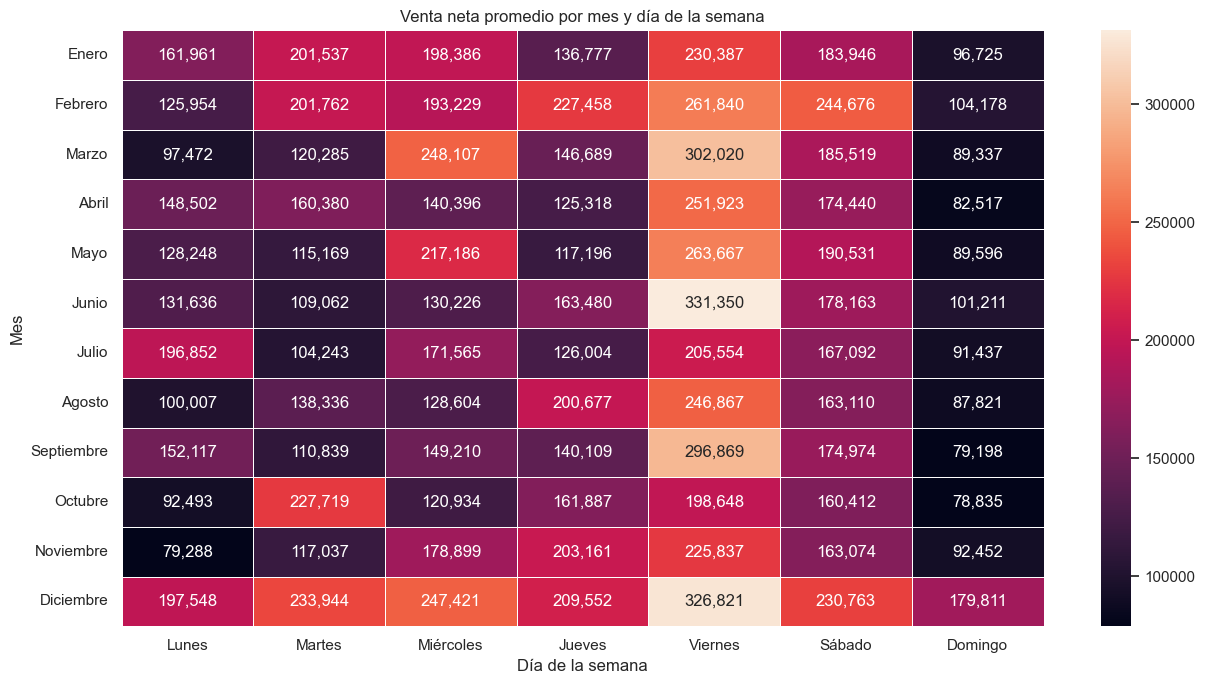

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\temporal\heatmap_mes_dia_semana.png


In [39]:
# ===============================
# Heatmap de venta promedio: mes vs día de semana
# ===============================

heatmap_mes_dia = (
    df.groupby(["MES_NOMBRE", "DIA_SEMANA_NOMBRE", "FECHA"])
    .agg(venta_neta=("VENTA_NETA", "sum"))
    .reset_index()
    .groupby(["MES_NOMBRE", "DIA_SEMANA_NOMBRE"])
    .agg(venta_neta_promedio=("venta_neta", "mean"))
    .reset_index()
)

heatmap_mes_dia["MES_NOMBRE"] = pd.Categorical(
    heatmap_mes_dia["MES_NOMBRE"],
    categories=orden_meses,
    ordered=True
)

heatmap_mes_dia["DIA_SEMANA_NOMBRE"] = pd.Categorical(
    heatmap_mes_dia["DIA_SEMANA_NOMBRE"],
    categories=orden_dias,
    ordered=True
)

tabla_heatmap = heatmap_mes_dia.pivot_table(
    index="MES_NOMBRE",
    columns="DIA_SEMANA_NOMBRE",
    values="venta_neta_promedio",
    observed=False
)

plt.figure(figsize=(13, 7))

sns.heatmap(
    tabla_heatmap,
    annot=True,
    fmt=",.0f",
    linewidths=0.5
)

plt.title("Venta neta promedio por mes y día de la semana")
plt.xlabel("Día de la semana")
plt.ylabel("Mes")
plt.tight_layout()

output_fig = TEMPORAL_FIGURES_DIR / "heatmap_mes_dia_semana.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

## Venta neta promedio por mes y día de la semana

El mapa de calor muestra la `VENTA_NETA` promedio combinando dos dimensiones temporales: mes y día de la semana. Esta visualización permite identificar patrones más específicos que no se observan únicamente con el análisis mensual o semanal por separado.

Se observa que el **viernes** es el día con mayor venta promedio en la mayoría de los meses. Los valores más altos se presentan especialmente en **junio-viernes**, con aproximadamente **331.350**, **diciembre-viernes**, con **326.821**, **marzo-viernes**, con **302.020**, y **septiembre-viernes**, con **296.869**. Esto confirma que el viernes es un día clave para la dinámica comercial.

El mes de **diciembre** muestra un comportamiento fuerte en casi todos los días de la semana, especialmente de lunes a sábado. Esto refuerza la hipótesis de una estacionalidad importante de fin de año, posiblemente asociada a mayor consumo, campañas comerciales y promociones.

Por otro lado, el **domingo** suele presentar los valores más bajos de venta neta promedio en la mayoría de los meses. Aun así, diciembre muestra un domingo más alto que el resto de meses, lo que indica que la temporada de fin de año también mejora el desempeño de días normalmente débiles.

También se identifican combinaciones particulares con ventas altas fuera del viernes, como **febrero-sábado**, **octubre-martes**, **diciembre-miércoles** y **noviembre-jueves**. Estos casos pueden estar asociados a eventos promocionales, fechas especiales o comportamientos comerciales puntuales.

En conclusión, la venta neta no depende solo del mes ni solo del día de la semana, sino de la combinación entre ambos. El viernes y diciembre destacan como factores de alto impacto, mientras que el domingo presenta menor desempeño general. Para futuros modelos predictivos, es recomendable incluir variables como `MES`, `DIA_SEMANA`, `FIN_SEMANA`, `FIN_MES` y posibles interacciones entre mes y día de la semana.

In [40]:
# ===============================
# Venta neta mensual por PDV
# ===============================

ventas_mensuales_pdv = (
    df.groupby(["ANIO", "MES", "PDV"])
    .agg(
        venta_neta=("VENTA_NETA", "sum"),
        tickets=("TICKET_ID", "nunique"),
        unidades=("CANT", "sum"),
        lineas=("NroReg", "count")
    )
    .reset_index()
)

ventas_mensuales_pdv["FECHA_MES"] = pd.to_datetime(
    ventas_mensuales_pdv["ANIO"].astype(str) + "-" + ventas_mensuales_pdv["MES"].astype(str) + "-01"
)

ventas_mensuales_pdv.head()

,ANIO,MES,PDV,venta_neta,tickets,unidades,lineas,FECHA_MES
0,2023,1,1255,"1,671,565.00",4783,"7,462.65",7059,2023-01-01
1,2023,1,1311,"2,800,817.00",5192,"9,642.18",8199,2023-01-01
2,2023,1,980,"993,375.00",2694,"5,492.72",3961,2023-01-01
3,2023,2,1255,"1,607,828.00",4185,"7,387.97",5905,2023-02-01
4,2023,2,1311,"3,009,910.00",5538,"9,740.07",8532,2023-02-01


## Construcción de la base mensual por PDV

La tabla muestra una agregación de las ventas a nivel de **año, mes y punto de venta (`PDV`)**. En esta vista, cada fila representa el comportamiento mensual de una tienda específica.

Se consolidan métricas como `venta_neta`, `tickets`, `unidades` y `lineas`, lo que permite comparar el desempeño de cada punto de venta mes a mes.

En los primeros registros se observa que, para enero de 2023, el PDV **1311** presenta la mayor venta neta, con **2.800.817**, seguido por el PDV **1255** con **1.671.565** y el PDV **980** con **993.375**. Esto confirma que el PDV 1311 tiene un peso comercial importante dentro de la base.

También se observa que el PDV 1311 concentra más tickets, unidades y líneas que los otros puntos de venta en los meses mostrados. Esto sugiere que su mayor venta neta está relacionada con un mayor volumen de transacciones y actividad comercial.

La variable `FECHA_MES` permite representar cada combinación mensual con una fecha estándar, lo cual facilita la construcción de gráficas de evolución temporal por tienda.

En conclusión, esta base mensual por PDV será útil para analizar tendencias, comparar tiendas, identificar diferencias de desempeño y revisar si la caída observada en 2024 afecta por igual a todos los puntos de venta o si se concentra en algunos PDV específicos.

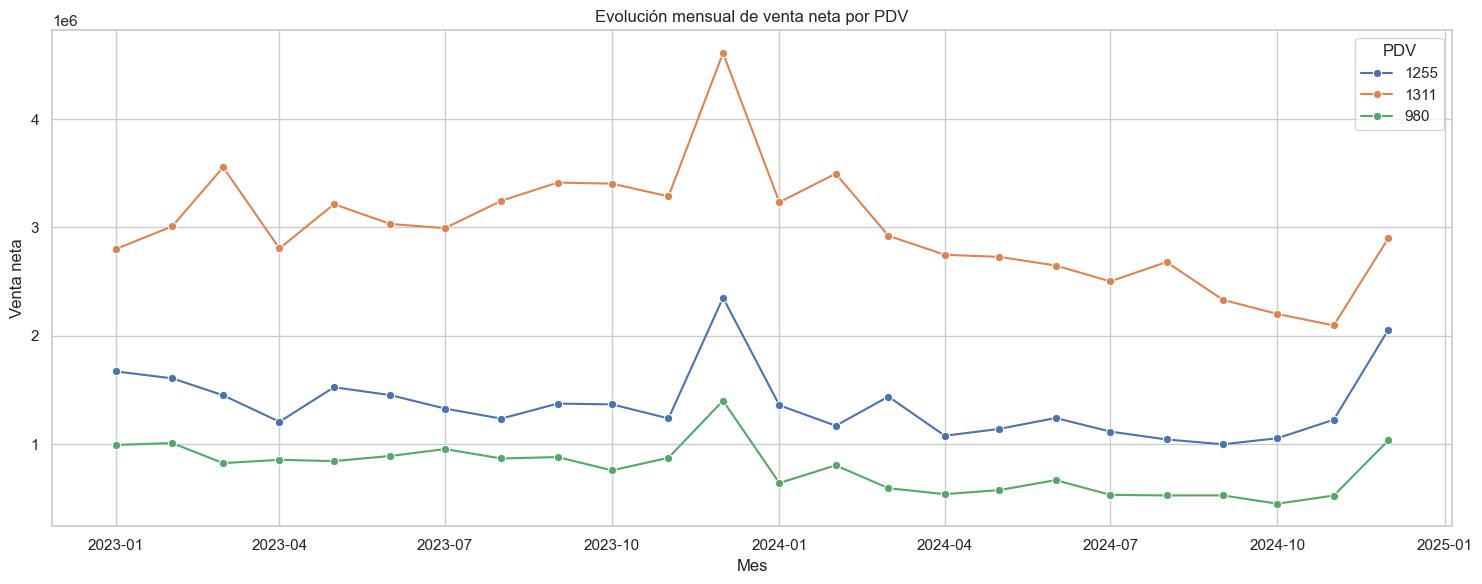

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\temporal\venta_mensual_por_pdv.png


In [41]:
# ===============================
# Evolución mensual por PDV
# ===============================

plt.figure(figsize=(15, 6))

sns.lineplot(
    data=ventas_mensuales_pdv,
    x="FECHA_MES",
    y="venta_neta",
    hue="PDV",
    marker="o"
)

plt.title("Evolución mensual de venta neta por PDV")
plt.xlabel("Mes")
plt.ylabel("Venta neta")
plt.tight_layout()

output_fig = TEMPORAL_FIGURES_DIR / "venta_mensual_por_pdv.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

## Evolución mensual de venta neta por PDV

La gráfica muestra la evolución mensual de la `VENTA_NETA` para cada punto de venta durante 2023 y 2024.

Se observa que el **PDV 1311** es consistentemente el punto de venta con mayor venta neta durante todo el periodo. Su comportamiento está por encima de los otros dos PDV en todos los meses, lo que confirma que es la tienda con mayor peso comercial dentro de la base.

El **PDV 1255** ocupa el segundo lugar en ventas. Aunque se mantiene por debajo del PDV 1311, presenta una dinámica similar en varios meses, especialmente en los picos de diciembre de 2023 y diciembre de 2024.

El **PDV 980** tiene la menor venta neta mensual durante casi todo el periodo. Aun así, sigue el mismo patrón general de los demás PDV: caída durante buena parte de 2024 y recuperación hacia diciembre.

Un punto importante es que los tres PDV presentan un pico fuerte en **diciembre de 2023**, lo que confirma que el aumento de ventas en ese mes no depende de una sola tienda, sino que parece ser un comportamiento general de la operación. También se observa recuperación en **diciembre de 2024**, aunque con niveles menores que los de diciembre de 2023.

Durante 2024, los tres PDV muestran una disminución frente a 2023, especialmente entre marzo y noviembre. Esto sugiere que la caída observada en el análisis anual no se concentra únicamente en un punto de venta, sino que afecta a toda la operación.

En conclusión, el PDV 1311 lidera claramente las ventas, seguido por 1255 y luego 980. Sin embargo, los tres puntos de venta comparten patrones temporales similares, especialmente la estacionalidad de diciembre y la desaceleración durante 2024. Por esta razón, `PDV` debe considerarse una variable clave para los análisis posteriores y futuros modelos predictivos.

In [42]:
# ===============================
# Exportar tablas del análisis temporal
# ===============================

output_excel = TABLES_DIR / "03_analisis_temporal.xlsx"

with pd.ExcelWriter(output_excel, engine="openpyxl") as writer:
    resumen_temporal_general.to_excel(writer, sheet_name="resumen_general", index=False)
    ventas_diarias.to_excel(writer, sheet_name="ventas_diarias", index=False)
    ventas_semanales.to_excel(writer, sheet_name="ventas_semanales", index=False)
    ventas_mensuales.to_excel(writer, sheet_name="ventas_mensuales", index=False)
    resumen_anual.to_excel(writer, sheet_name="resumen_anual", index=False)
    comparacion_mensual.to_excel(writer, sheet_name="comparacion_mensual", index=False)
    resumen_dia_semana.to_excel(writer, sheet_name="dia_semana", index=False)
    resumen_mes.to_excel(writer, sheet_name="mes", index=False)
    resumen_quincena.to_excel(writer, sheet_name="quincena", index=False)
    resumen_fin_semana.to_excel(writer, sheet_name="fin_semana", index=False)
    resumen_fin_mes.to_excel(writer, sheet_name="fin_mes", index=False)
    top_dias_venta.to_excel(writer, sheet_name="top_dias_venta", index=False)
    bottom_dias_venta.to_excel(writer, sheet_name="bottom_dias_venta", index=False)
    dias_atipicos.to_excel(writer, sheet_name="dias_atipicos", index=False)
    ventas_mensuales_pdv.to_excel(writer, sheet_name="mensual_pdv", index=False)

print(f"Archivo Excel exportado correctamente en: {output_excel}")

Archivo Excel exportado correctamente en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\tables\03_analisis_temporal.xlsx


## Conclusiones del análisis temporal

A partir del análisis temporal de la base de ventas, se identifican varios puntos relevantes:

1. La base permite analizar el comportamiento de las ventas con una granularidad diaria durante el periodo disponible.

2. La variable `VENTA_NETA` muestra variaciones importantes a lo largo del tiempo, por lo que resulta necesario analizar la tendencia diaria, semanal y mensual antes de construir cualquier modelo predictivo.

3. La comparación mensual entre 2023 y 2024 permite identificar cambios en el nivel de ventas entre ambos años. Esta comparación es importante para detectar posibles caídas, crecimientos o cambios estructurales en la operación.

4. El análisis por día de la semana permite observar si existen patrones recurrentes de consumo asociados a días específicos.

5. El análisis por mes permite identificar posibles efectos estacionales o periodos de mayor actividad comercial.

6. La comparación entre quincenas es relevante porque en el contexto comercial colombiano pueden existir diferencias asociadas a fechas de pago, ciclos de consumo y cierres comerciales.

7. El análisis de fin de semana vs días hábiles permite evaluar si el comportamiento de compra cambia según el tipo de día.

8. El análisis de fin de mes muestra si existen incrementos de venta asociados a cierres mensuales.

9. Los días atípicos detectados deben analizarse con cuidado. No necesariamente son errores; pueden estar asociados a promociones, eventos comerciales, cambios operativos o comportamientos especiales de la demanda.

10. La relación entre promociones y ventas debe estudiarse con mayor profundidad en el notebook específico de promociones y descuentos.

11. Para un futuro modelo de predicción, las variables temporales más importantes a considerar serían año, mes, día, día de la semana, semana del año, quincena, fin de semana, fin de mes y variables relacionadas con promociones.